In [39]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from Data_Handling import get_data_auto
from LSTM_Price_Predictor import LSTMPricePredictor

# LSTM Intraday Testing - 1-Minute Bars

This notebook tests LSTM predictions on 1-minute timeframe data.

**Current Configuration:**
- Training: 1 month of data (Jan 2023, ~7,800 bars)
- Lookback: 1170 minutes (3 trading days of history)
- Testing: Rolling 3-day windows (Feb 2023)
- Prediction horizon: 10 minutes ahead (recursive)
- Model: 1-layer LSTM, 50 units, 20 epochs

**Strategy:** Train on 1 month → Use 3-day lookback → Predict 10 min ahead (similar to RSI approach)

**Memory estimate:** ~500 MB for 1 month of minute data

## 1. Configuration

In [40]:
# Symbol and timeframe
SYMBOL = "SPY"
TIMEFRAME_UNIT = "Minute"  # Intraday minute bars
MULTIPLIER = 1              # 1-minute bars

# Training period - 1 month of data
TRAIN_START = "2025-01-01"
TRAIN_END = "2025-01-31"  # 1 month (~7,800 minute bars)

# Testing period - Will use rolling 3-day windows
TEST_START = "2025-02-01"
TEST_END = "2025-02-28"  # Next month for testing

# ============================================================================
# MODEL PARAMETERS - Key factors for intraday trading performance
# ============================================================================

# TEMPORAL PARAMETERS (What history & future to consider)
# ---------------------------------------------------------------
LOOKBACK_WINDOW = 585      # How much price history to analyze
                            # 585 minutes = 1.5 trading days (390 min/day * 1.5)
                            # Options to test:
                            # - 390: 1 full trading day
                            # - 780: 2 trading days
                            # - 1170: 3 trading days (CURRENT - long-term patterns)
                            # - 1560: 4 trading days
                            # Trade-off: More history = better context but slower, potential overfitting

PREDICTION_HORIZON = 1     # How many minutes ahead to predict (recursive)
                            # 10 minutes = multiple prediction steps
                            # Options: 1, 5, 10, 15, 30
                            # Trade-off: Shorter = more accurate but less trading time

# ARCHITECTURE PARAMETERS (Model complexity)
# ---------------------------------------------------------------
LSTM_UNITS = 50             # Neurons per LSTM layer (pattern recognition capacity)
                            # Options: 32, 50, 64, 100, 128
                            # Trade-off: More units = more patterns but slower, risk overfitting

NUM_LAYERS = 2              # Depth of LSTM stack (hierarchical pattern learning)
                            # Options: 1, 2, 3
                            # Trade-off: More layers = complex patterns but overfitting risk

DROPOUT = 0.2               # Regularization (prevents overfitting)
                            # Options: 0.1, 0.2, 0.3, 0.5
                            # Trade-off: Higher dropout = less overfitting but may underfit

# TRAINING PARAMETERS (How the model learns)
# ---------------------------------------------------------------
EPOCHS = 10                 # Training iterations through full dataset
                            # Increased for longer lookback (more complex patterns to learn)
                            # Options: 5 (fast test), 20 (balanced), 50-100 (thorough)
                            # Trade-off: More epochs = better fit but slower, risk overfitting

BATCH_SIZE = 64             # Samples processed before weight update
                            # Options: 32, 64, 128, 256
                            # Trade-off: Larger = faster, more stable but less frequent updates

LEARNING_RATE = 0.01       # Step size for weight adjustments (Adam optimizer default)
                            # Options: 0.0001 (slow), 0.001 (default), 0.01 (fast)
                            # Trade-off: Higher = faster training but may overshoot optimal

# PREDICTION MODE
# ---------------------------------------------------------------
PREDICTION_MODE = 'direct' # How multi-step predictions are generated
                              # 'recursive': Predict 1-step, feed back for next or use "direct"
                              # Trade-off: More stable for longer horizons

# ADDITIONAL PARAMETERS NOT YET IMPLEMENTED
# ---------------------------------------------------------------
# Consider adding to LSTM_Price_Predictor.py:
# - BIDIRECTIONAL: Use future context (not suitable for live trading but good for analysis)
# - ATTENTION_MECHANISM: Focus on important time steps
# - LEARNING_RATE_SCHEDULE: Reduce learning rate during training
# - GRADIENT_CLIPPING: Prevent exploding gradients
# - L2_REGULARIZATION: Additional overfitting prevention
# - VALIDATION_SPLIT: Currently 0.2, could test 0.1-0.3

# Model name
MODEL_NAME = f"lstm_intraday_{SYMBOL}_{TRAIN_START}_{TRAIN_END}_1min"
RETRAIN = False  # Set True to force retraining

## 2. Load Training Data

In [41]:
print(f"Loading training data: {TRAIN_START} to {TRAIN_END}")
print(f"Timeframe: {MULTIPLIER}-{TIMEFRAME_UNIT} bars")

train_data = get_data_auto(SYMBOL, start=TRAIN_START, end=TRAIN_END,
                           timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"\nTraining data loaded: {len(train_data):,} bars")
print(f"Date range: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Memory usage: {train_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
train_data.tail()

Loading training data: 2025-01-01 to 2025-01-31
Timeframe: 1-Minute bars

Training data loaded: 15,254 bars
Date range: 2025-01-01 00:00:00+00:00 to 2025-01-30 23:59:00+00:00
Memory usage: 0.7 MB

Training data loaded: 15,254 bars
Date range: 2025-01-01 00:00:00+00:00 to 2025-01-30 23:59:00+00:00
Memory usage: 0.7 MB


field,Open,High,Low,Close,Volume
timestamp,,,,,
2025-01-30 23:53:00+00:00,605.59,605.60,605.51,605.51,1609.0
2025-01-30 23:55:00+00:00,605.79,605.79,605.79,605.79,314.0
2025-01-30 23:57:00+00:00,605.95,606.00,605.95,606.00,1297.0
2025-01-30 23:58:00+00:00,605.90,605.90,605.90,605.90,415.0
2025-01-30 23:59:00+00:00,605.93,605.93,605.83,605.83,1174.0


## 3. Load Testing Data

In [42]:
print(f"Loading testing data: {TEST_START} to {TEST_END}")

test_data = get_data_auto(SYMBOL, start=TEST_START, end=TEST_END,
                         timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"\nTesting data loaded: {len(test_data):,} bars")
print(f"Date range: {test_data.index[0]} to {test_data.index[-1]}")
print(f"Memory usage: {test_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
test_data.tail()

Loading testing data: 2025-02-01 to 2025-02-28

Testing data loaded: 14,090 bars
Date range: 2025-02-01 00:02:00+00:00 to 2025-02-28 00:00:00+00:00
Memory usage: 0.6 MB

Testing data loaded: 14,090 bars
Date range: 2025-02-01 00:02:00+00:00 to 2025-02-28 00:00:00+00:00
Memory usage: 0.6 MB


field,Open,High,Low,Close,Volume
timestamp,,,,,
2025-02-27 23:56:00+00:00,585.9793,586.06,585.9793,586.06,1430.0
2025-02-27 23:57:00+00:00,586.0007,586.06,586.0001,586.04,3178.0
2025-02-27 23:58:00+00:00,586.1000,586.10,586.0000,586.00,1557.0
2025-02-27 23:59:00+00:00,586.0200,586.05,586.0200,586.05,746.0
2025-02-28 00:00:00+00:00,586.1500,586.20,586.1200,586.20,2561.0


## 4. Train or Load Model

In [43]:
import os

# Initialize predictor
predictor = LSTMPricePredictor(
    lookback_window=LOOKBACK_WINDOW,
    prediction_horizon=PREDICTION_HORIZON,
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    prediction_mode=PREDICTION_MODE,
    verbose=1
)

model_path = os.path.join('models', f"{MODEL_NAME}.keras")

if os.path.exists(model_path) and not RETRAIN:
    print(f"\n{'='*60}")
    print("Loading existing model...")
    print(f"{'='*60}")
    predictor.load_model(MODEL_NAME)
else:
    print(f"\n{'='*60}")
    print("Training new model on 2023 intraday data...")
    print("Expected time: 10 minutes")
    print(f"{'='*60}"), 
    predictor.fit(train_data, validation_split=0.2, early_stopping_patience=10)
    predictor.save_model(MODEL_NAME)

print("\nModel ready!")


Training new model on 2023 intraday data...
Expected time: 10 minutes
Computing returns from 15254 candles...
Creating sequences (lookback=585, horizon=1)...
Generated 14669 training sequences
Input shape: (14669, 585, 5), Output shape: (14669, 1)
Building LSTM model...
Model parameters: 31,451
Training model...
Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 69s 363ms/step - loss: 0.9366 - mae: 0.5119 - val_loss: 0.7957 - val_mae: 0.5980
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 69s 363ms/step - loss: 0.9366 - mae: 0.5119 - val_loss: 0.7957 - val_mae: 0.5980
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 66s 360ms/step - loss: 0.9350 - mae: 0.5114 - val_loss: 0.7967 - val_mae: 0.5979
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 66s 360ms/step - loss: 0.9350 - mae: 0.5114 - val_loss: 0.7967 - val_mae: 0.5979
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 86s 379ms/step - loss: 0.9346 - mae: 0.5109 - val_loss: 0.7983 - val_mae: 0.5998
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 86s 379ms/step - loss: 0.9346 - mae: 0.5

## 5. Generate Predictions on Test Data

In [44]:
print(f"Generating predictions for {len(test_data):,} test bars...")
print("Expected time: 1-3 minutes (batched processing)\n")

predictions = predictor.predict(test_data)

print(f"\nPredictions generated: {len(predictions):,} bars")
print(f"Date range: {predictions.index[0]} to {predictions.index[-1]}")
predictions.tail(10)

Generating predictions for 14,090 test bars...
Expected time: 1-3 minutes (batched processing)

Generating 13505 predictions in batched mode...
212/212 ━━━━━━━━━━━━━━━━━━━━ 31s 145ms/step
212/212 ━━━━━━━━━━━━━━━━━━━━ 31s 145ms/step
Predictions complete!

Predictions generated: 13,505 bars
Date range: 2025-02-03 18:37:00+00:00 to 2025-02-28 00:00:00+00:00
Predictions complete!

Predictions generated: 13,505 bars
Date range: 2025-02-03 18:37:00+00:00 to 2025-02-28 00:00:00+00:00


,actual_price,pred_price_1
timestamp,,
2025-02-27 23:48:00+00:00,585.8700,590.638245
2025-02-27 23:49:00+00:00,585.9400,579.756775
2025-02-27 23:50:00+00:00,585.9798,572.405457
2025-02-27 23:53:00+00:00,585.9217,569.302612
2025-02-27 23:55:00+00:00,585.9800,573.874390
2025-02-27 23:56:00+00:00,586.0600,574.816833
2025-02-27 23:57:00+00:00,586.0400,575.559570
2025-02-27 23:58:00+00:00,586.0000,578.606201
2025-02-27 23:59:00+00:00,586.0500,585.964172


## 6. Overall Performance Metrics

In [45]:
# Evaluate overall performance (using cached predictions)
print("Evaluating model performance...\n")
eval_results = predictor.evaluate(predictions=predictions)

print(f"\n{'='*60}")
print("OVERALL PERFORMANCE - 2024 Test Data")
print(f"{'='*60}")

# Display the full evaluation results
print(eval_results.to_string())

print(f"\n{'='*60}")

Evaluating model performance...


OVERALL PERFORMANCE - 2024 Test Data
              MAE       RMSE      MAPE  Direction_Accuracy  Hit_Rate_0.1%  Hit_Rate_0.5%  Hit_Rate_1.0%
step_1  10.893578  16.513558  1.810373           48.304206       4.842651      23.887449      43.561644



## 7. Directional Accuracy Analysis

In [46]:
# Get directional accuracy (using cached predictions)
dir_accuracy = predictor.get_directional_accuracy(predictions=predictions)

print(f"\n{'='*60}")
print("DIRECTIONAL ACCURACY - All Horizons")
print(f"{'='*60}")

# Display the full directional accuracy results
print(dir_accuracy.to_string())

print(f"\n{'='*60}")


DIRECTIONAL ACCURACY - All Horizons
         Accuracy
step_1  48.304206



## 8. Hit Rate Analysis (Tolerance-Based)

In [47]:
# Get hit rates at various tolerance levels (using cached predictions)
tolerance_levels = [0.001, 0.005, 0.01, 0.02, 0.05]  # 0.1%, 0.5%, 1%, 2%, 5%
hit_rates = predictor.get_hit_rates(predictions=predictions, tolerance_levels=tolerance_levels)

print(f"\n{'='*60}")
print("HIT RATE ANALYSIS - How Often Predictions Are 'Close Enough'")
print(f"{'='*60}")

# Display the full hit rate results
print(hit_rates.to_string())

print(f"\n{'='*60}")


HIT RATE ANALYSIS - How Often Predictions Are 'Close Enough'
        ±0.1%_HitRate  ±0.1%_Hits  ±0.1%_Misses  ±0.5%_HitRate  ±0.5%_Hits  ±0.5%_Misses  ±1.0%_HitRate  ±1.0%_Hits  ±1.0%_Misses  ±2.0%_HitRate  ±2.0%_Hits  ±2.0%_Misses  ±5.0%_HitRate  ±5.0%_Hits  ±5.0%_Misses
step_1       4.842651       654.0       12851.0      23.887449      3226.0       10279.0      43.561644      5883.0        7622.0      69.514994      9388.0        4117.0      93.706035     12655.0         850.0



## 9. Time-of-Day Analysis


HOUR BOUNDARIES (CLEAN ON-THE-HOUR CUTOFFS)
Hour  9: 09:31:00 to 09:59:00 (Market opens at 9:30)
Hour 10: 10:00:00 to 10:59:00
Hour 11: 11:00:00 to 11:59:00
Hour 12: 12:00:00 to 12:59:00
Hour 13: 13:00:00 to 13:59:00
Hour 14: 14:00:00 to 14:59:00
Hour 15: 15:00:00 to 15:59:00
Hour 16: 16:00:00 to 16:00:00 (Market closes at 4:00)

DIRECTIONAL ACCURACY BY HOUR (1-minute ahead)
       accuracy  count
hour                  
9     48.780488    246
10    46.796657    359
11    48.297872    470
12    48.764629    769
13    46.193952    959
14    47.378833   1011
15    49.509804   1020
16    58.823529     17



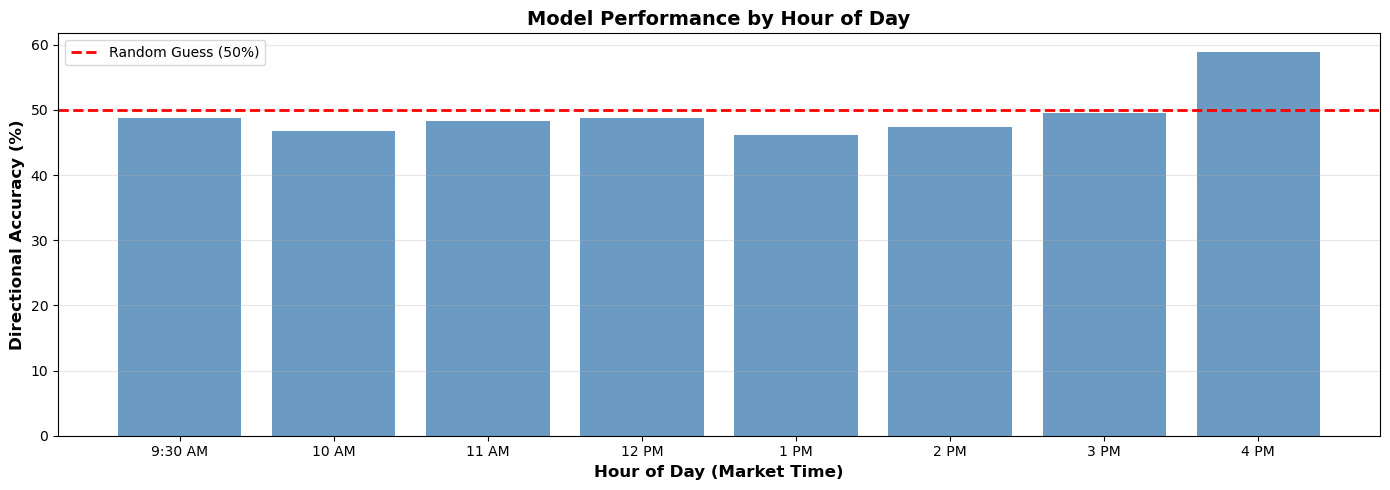

In [48]:
# Analyze performance by hour of day
predictions['hour'] = predictions.index.hour
predictions['minute'] = predictions.index.minute

# Filter to regular trading hours only (9:30 AM - 4:00 PM)
# Hour 9 with minute >= 30, or hours 10-15 (full hours), or hour 16 with minute == 0
regular_hours_mask = (
    ((predictions['hour'] == 9) & (predictions['minute'] >= 30)) |  # 9:30 AM onwards
    ((predictions['hour'] >= 10) & (predictions['hour'] <= 15)) |    # 10 AM - 3:59 PM
    ((predictions['hour'] == 16) & (predictions['minute'] == 0))     # Exactly 4:00 PM
)
trading_hours_predictions = predictions[regular_hours_mask].copy()

# Show exact hour boundaries for clarity
print(f"\n{'='*60}")
print("HOUR BOUNDARIES (CLEAN ON-THE-HOUR CUTOFFS)")
print(f"{'='*60}")
for hour in range(9, 17):
    hour_data = trading_hours_predictions[trading_hours_predictions['hour'] == hour]
    if len(hour_data) > 0:
        min_time = hour_data.index.min().strftime('%H:%M:%S')
        max_time = hour_data.index.max().strftime('%H:%M:%S')
        if hour == 9:
            print(f"Hour {hour:2d}: {min_time} to {max_time} (Market opens at 9:30)")
        elif hour == 16:
            print(f"Hour {hour:2d}: {min_time} to {max_time} (Market closes at 4:00)")
        else:
            print(f"Hour {hour:2d}: {min_time} to {max_time}")
print(f"{'='*60}\n")

# Calculate directional accuracy by hour for 1-minute horizon
pred_col = 'pred_price_1'
# Get actual future price (1 minute ahead)
trading_hours_predictions['actual_future'] = trading_hours_predictions['actual_price'].shift(-1)
trading_hours_predictions['direction_correct'] = (
    np.sign(trading_hours_predictions[pred_col] - trading_hours_predictions['actual_price']) == 
    np.sign(trading_hours_predictions['actual_future'] - trading_hours_predictions['actual_price'])
)

hourly_accuracy = trading_hours_predictions.groupby('hour').agg({
    'direction_correct': 'mean',
    pred_col: 'count'
}).rename(columns={pred_col: 'count', 'direction_correct': 'accuracy'})

hourly_accuracy['accuracy'] *= 100  # Convert to percentage

print(f"{'='*60}")
print("DIRECTIONAL ACCURACY BY HOUR (1-minute ahead)")
print(f"{'='*60}")
print(hourly_accuracy.to_string())
print(f"\n{'='*60}")

# Visualize
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(hourly_accuracy.index, hourly_accuracy['accuracy'], color='steelblue', alpha=0.8)
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random Guess (50%)')
ax.set_xlabel('Hour of Day (Market Time)', fontsize=12, fontweight='bold')
ax.set_ylabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(9, 17))
ax.set_xticklabels(['9:30 AM', '10 AM', '11 AM', '12 PM', '1 PM', '2 PM', '3 PM', '4 PM'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9a-0. Day-by-Day Sample Count Investigation

Why does Hour 10 have 566 samples vs Hour 14-15 with 1020?

In [49]:
# ============================================================================
# Investigate why Hour 10 has only 566 samples vs Hour 14-15 with 1020
# ============================================================================

print("="*80)
print("DAY-BY-DAY HOURLY SAMPLE COUNT BREAKDOWN")
print("="*80)

# Get all unique dates in test predictions
trading_hours_predictions['date'] = trading_hours_predictions.index.date
unique_dates = sorted(trading_hours_predictions['date'].unique())

print(f"\nTotal unique trading days in test period: {len(unique_dates)}")
print(f"Date range: {unique_dates[0]} to {unique_dates[-1]}")

# Create day-by-day hourly breakdown
daily_hourly_counts = trading_hours_predictions.groupby(['date', 'hour']).size().unstack(fill_value=0)

print(f"\nSamples per hour, per day:")
print(daily_hourly_counts.to_string())

# Calculate totals
print(f"\n" + "="*80)
print("TOTAL SAMPLES PER HOUR (across all days):")
print("="*80)
hourly_totals = daily_hourly_counts.sum()
for hour in range(9, 17):
    if hour in hourly_totals.index:
        count = hourly_totals[hour]
        days_with_data = (daily_hourly_counts[hour] > 0).sum()
        avg_per_day = count / days_with_data if days_with_data > 0 else 0
        print(f"Hour {hour:2d}: {count:4d} samples across {days_with_data:2d} days (avg {avg_per_day:.1f}/day)")

# Expected counts analysis
print(f"\n" + "="*80)
print("EXPECTED VS ACTUAL:")
print("="*80)
print(f"Expected samples per full hour: 60 minutes")
print(f"Expected samples for Hour 9: 30 minutes (market opens 9:30)")
print(f"Expected samples for Hour 16: 1 minute (market closes 4:00)")
print(f"\nFor {len(unique_dates)} trading days:")
for hour in range(9, 17):
    if hour in hourly_totals.index:
        actual = hourly_totals[hour]
        if hour == 9:
            expected = 30 * len(unique_dates)
            print(f"  Hour {hour:2d}: Expected ~{expected:4d}, Actual {actual:4d} ({actual/expected*100:5.1f}%)")
        elif hour == 16:
            expected = 1 * len(unique_dates)
            print(f"  Hour {hour:2d}: Expected ~{expected:4d}, Actual {actual:4d} ({actual/expected*100:5.1f}%)")
        else:
            expected = 60 * len(unique_dates)
            print(f"  Hour {hour:2d}: Expected ~{expected:4d}, Actual {actual:4d} ({actual/expected*100:5.1f}%)")

# Find days with missing data in morning hours
print(f"\n" + "="*80)
print("DAYS WITH INCOMPLETE MORNING HOURS:")
print("="*80)
for date in unique_dates[:10]:  # Check first 10 days
    row = daily_hourly_counts.loc[date]
    if row[10] < 50:  # Hour 10 should have ~60 samples
        print(f"{date}: Hour 9={row[9]:2d}, Hour 10={row[10]:2d}, Hour 11={row[11]:2d}, Hour 12={row[12]:2d}")

print(f"\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print(f"If Hour 10 is consistently low across all days, the issue is:")
print(f"  1. Lookback requirement (1170 min = 3 days) means first 3 days have no predictions")
print(f"  2. Early hours on remaining days still affected if prediction generation is sequential")
print(f"  3. Or there may be actual data gaps in the raw 1-minute bars")
print("="*80)

DAY-BY-DAY HOURLY SAMPLE COUNT BREAKDOWN

Total unique trading days in test period: 17
Date range: 2025-02-04 to 2025-02-27

Samples per hour, per day:
hour        9   10  11  12  13  14  15  16
date                                      
2025-02-04  18  27  37  57  59  60  60   1
2025-02-05  19  23  27  44  57  60  60   1
2025-02-06  14  21  35  45  51  59  60   1
2025-02-07   8   7  19  38  57  59  60   1
2025-02-10  13  14  27  36  59  60  60   1
2025-02-11  18  23  18  48  58  58  60   1
2025-02-12  15  27   8  45  60  60  60   1
2025-02-13  16  22  24  37  58  60  60   1
2025-02-14  11  23  37  35  54  60  60   1
2025-02-18  10  12  19  36  49  60  60   1
2025-02-19  10  22  31  37  56  58  60   1
2025-02-20   7  16  25  48  52  59  60   1
2025-02-21   5  25  12  41  54  59  60   1
2025-02-24  25  29  37  56  58  60  60   1
2025-02-25  19  24  45  55  58  59  60   1
2025-02-26  19  18  29  54  59  60  60   1
2025-02-27  19  26  40  57  60  60  60   1

TOTAL SAMPLES PER HOUR (across

In [50]:
# ============================================================================
# Check if the missing data is in the SOURCE data or prediction process
# ============================================================================

print("="*80)
print("CHECKING RAW TEST DATA FOR MISSING MORNING BARS")
print("="*80)

# Check raw test_data (before predictions)
test_data['hour'] = test_data.index.hour
test_data['date'] = test_data.index.date

# Count raw bars per hour per day
raw_hourly_counts = test_data.groupby(['date', 'hour']).size().unstack(fill_value=0)

print(f"\nRAW TEST DATA - Samples per hour, per day:")
print(raw_hourly_counts.to_string())

print(f"\n" + "="*80)
print("RAW DATA TOTALS PER HOUR:")
print("="*80)
raw_hourly_totals = raw_hourly_counts.sum()
for hour in range(9, 17):
    if hour in raw_hourly_totals.index:
        count = raw_hourly_totals[hour]
        days = (raw_hourly_counts[hour] > 0).sum()
        avg = count / days if days > 0 else 0
        print(f"Hour {hour:2d}: {count:4d} samples across {days:2d} days (avg {avg:.1f}/day)")

print(f"\n" + "="*80)
print("DIAGNOSIS:")
print("="*80)
if raw_hourly_totals[10] < 900:  # Should be ~1020
    print("✗ PROBLEM: Raw source data is missing morning bars!")
    print("  → This is a DATA QUALITY issue, not a prediction issue")
    print("  → Your 1-minute SPY data has gaps in morning hours")
    print("  → Solution: Re-download data or use a different data source")
else:
    print("✓ Raw data is complete")
    print("✗ PROBLEM: Prediction process is dropping morning samples")
    print("  → Issue with how the model generates predictions")
print("="*80)

CHECKING RAW TEST DATA FOR MISSING MORNING BARS

RAW TEST DATA - Samples per hour, per day:
hour        0   1   9   10  11  12  13  14  15  16  17  18  19  20  21  22  23
date                                                                          
2025-02-01  42   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
2025-02-03   0   0  47  47  53  59  60  60  60  60  60  60  60  60  60  53  54
2025-02-04  47   0  43  27  37  57  59  60  60  60  60  60  60  60  59  52  37
2025-02-05  47   0  41  23  27  44  57  60  60  60  60  60  60  60  57  36  37
2025-02-06  40   0  30  21  35  45  51  59  60  60  60  60  60  60  59  47  36
2025-02-07  31   0  18   7  19  38  57  59  60  60  60  60  60  60  56  48  33
2025-02-08  27   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
2025-02-10   0   0  26  14  27  36  59  60  60  60  60  60  60  60  52  34  44
2025-02-11  50   0  35  23  18  48  58  58  60  60  60  60  60  60  56  38  35
2025-02-12  24   0  34  27   8  45  60 

## 9a. Statistical Significance Testing

Test if model performance is statistically better than random chance (50%).

In [51]:
from scipy import stats

print(f"\n{'='*80}")
print("STATISTICAL SIGNIFICANCE TESTS")
print(f"{'='*80}\n")

# Test 1: Overall Model Performance (Binomial Test)
# H0: Model accuracy = 50% (random guessing)
# H1: Model accuracy > 50% (model has predictive power)

n_predictions = len(trading_hours_predictions['direction_correct'].dropna())
n_correct = trading_hours_predictions['direction_correct'].sum()
overall_accuracy = n_correct / n_predictions

# Binomial test (one-tailed: testing if accuracy > 50%)
p_value_overall = stats.binomtest(int(n_correct), n_predictions, 0.5, alternative='greater').pvalue

print("=" * 80)
print("TEST 1: OVERALL MODEL PERFORMANCE")
print("=" * 80)
print(f"Null Hypothesis: Model accuracy = 50% (random chance)")
print(f"Alternative: Model accuracy > 50%")
print(f"\nResults:")
print(f"  Total Predictions: {n_predictions:,}")
print(f"  Correct Predictions: {int(n_correct):,}")
print(f"  Accuracy: {overall_accuracy*100:.2f}%")
print(f"  P-value: {p_value_overall:.6f}")
print(f"\nConclusion:")
if p_value_overall < 0.01:
    print(f"  ✓✓ HIGHLY SIGNIFICANT (p < 0.01): Model significantly outperforms random chance")
elif p_value_overall < 0.05:
    print(f"  ✓ SIGNIFICANT (p < 0.05): Model outperforms random chance")
elif p_value_overall < 0.10:
    print(f"  ~ MARGINALLY SIGNIFICANT (p < 0.10): Weak evidence of predictive power")
else:
    print(f"  ✗ NOT SIGNIFICANT (p >= 0.10): Cannot reject random chance hypothesis")

print("\n" + "=" * 80)
print("TEST 2: SIGNIFICANCE BY HOUR OF DAY")
print("=" * 80)
print("Testing each hour independently against 50% baseline\n")

hourly_significance = []

for hour in hourly_accuracy.index:
    # Get predictions for this hour
    hour_data = trading_hours_predictions[trading_hours_predictions['hour'] == hour]
    hour_n = len(hour_data['direction_correct'].dropna())
    hour_correct = hour_data['direction_correct'].sum()
    hour_acc = hour_correct / hour_n if hour_n > 0 else 0
    
    # Binomial test for this hour
    if hour_n > 0:
        hour_pval = stats.binomtest(int(hour_correct), hour_n, 0.5, alternative='two-sided').pvalue
    else:
        hour_pval = 1.0
    
    # Determine significance level
    if hour_pval < 0.01:
        sig_level = "***"
        sig_text = "Highly Sig"
    elif hour_pval < 0.05:
        sig_level = "**"
        sig_text = "Significant"
    elif hour_pval < 0.10:
        sig_level = "*"
        sig_text = "Marginal"
    else:
        sig_level = ""
        sig_text = "Not Sig"
    
    hourly_significance.append({
        'hour': hour,
        'accuracy': hour_acc * 100,
        'n_samples': hour_n,
        'p_value': hour_pval,
        'significance': sig_level,
        'sig_text': sig_text
    })

sig_df = pd.DataFrame(hourly_significance)
print(sig_df.to_string(index=False))

print("\n" + "=" * 80)
print("SIGNIFICANCE LEGEND")
print("=" * 80)
print("  *** : p < 0.01 (Highly Significant)")
print("  **  : p < 0.05 (Significant)")
print("  *   : p < 0.10 (Marginally Significant)")
print("      : p >= 0.10 (Not Significant)")

# Test 3: Chi-Square Test for Hour Independence
# Test if accuracy varies significantly across hours
print("\n" + "=" * 80)
print("TEST 3: DOES PERFORMANCE VARY BY HOUR?")
print("=" * 80)

# Create contingency table
contingency = []
for hour in hourly_accuracy.index:
    hour_data = trading_hours_predictions[trading_hours_predictions['hour'] == hour]
    correct = int(hour_data['direction_correct'].sum())
    incorrect = len(hour_data) - correct
    contingency.append([correct, incorrect])

# Chi-square test
chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency)

print(f"Null Hypothesis: Accuracy is the same across all hours")
print(f"Alternative: Accuracy varies by hour")
print(f"\nResults:")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  P-value: {p_value_chi:.6f}")
print(f"\nConclusion:")
if p_value_chi < 0.01:
    print(f"  ✓✓ HIGHLY SIGNIFICANT: Performance varies significantly by hour")
elif p_value_chi < 0.05:
    print(f"  ✓ SIGNIFICANT: Performance varies by hour")
else:
    print(f"  ✗ NOT SIGNIFICANT: No evidence of hour-specific performance differences")

print("\n" + "=" * 80)
print("PRACTICAL INTERPRETATION")
print("=" * 80)
print("• Statistically significant ≠ Profitable trading strategy")
print("• Consider transaction costs, slippage, and risk management")
print("• Small p-values on large datasets can occur with tiny effect sizes")
print("• Focus on hours with both high accuracy AND statistical significance")
print("=" * 80)


STATISTICAL SIGNIFICANCE TESTS

TEST 1: OVERALL MODEL PERFORMANCE
Null Hypothesis: Model accuracy = 50% (random chance)
Alternative: Model accuracy > 50%

Results:
  Total Predictions: 4,851
  Correct Predictions: 2,327
  Accuracy: 47.97%
  P-value: 0.997767

Conclusion:
  ✗ NOT SIGNIFICANT (p >= 0.10): Cannot reject random chance hypothesis

TEST 2: SIGNIFICANCE BY HOUR OF DAY
Testing each hour independently against 50% baseline

 hour  accuracy  n_samples  p_value significance    sig_text
    9 48.780488        246 0.749961                  Not Sig
   10 46.796657        359 0.245557                  Not Sig
   11 48.297872        470 0.489042                  Not Sig
   12 48.764629        769 0.516302                  Not Sig
   13 46.193952        959 0.020024           ** Significant
   14 47.378833       1011 0.101915                  Not Sig
   15 49.509804       1020 0.778112                  Not Sig
   16 58.823529         17 0.629059                  Not Sig

SIGNIFICANCE L

## 9a-1. Sample Count Diagnostics

Understanding why sample counts differ by hour

In [52]:
print(f"\n{'='*80}")
print("SAMPLE COUNT DIAGNOSTICS")
print(f"{'='*80}\n")

# 1. Check how many trading days we have
unique_test_dates = test_data.index.date
unique_dates_count = len(set(unique_test_dates))
print(f"1. TRADING DAYS IN TEST PERIOD")
print(f"   Total unique trading days: {unique_dates_count}")
print(f"   Date range: {test_data.index[0].date()} to {test_data.index[-1].date()}")

# 2. Check predictions coverage
pred_dates = predictions.index.date
pred_unique_dates = len(set(pred_dates))
print(f"\n2. PREDICTIONS COVERAGE")
print(f"   Days with predictions: {pred_unique_dates}")
print(f"   First prediction: {predictions.index[0]}")
print(f"   Last prediction: {predictions.index[-1]}")
print(f"   Missing days: {unique_dates_count - pred_unique_dates} (likely due to {LOOKBACK_WINDOW}-minute lookback requirement)")

# 3. Check trading hours filtering
print(f"\n3. TRADING HOURS FILTERING")
print(f"   Original predictions: {len(predictions):,}")
print(f"   After trading hours filter: {len(trading_hours_predictions):,}")
print(f"   Removed (pre/post market): {len(predictions) - len(trading_hours_predictions):,}")

# 4. Check shift(-1) impact
valid_predictions = trading_hours_predictions['direction_correct'].notna().sum()
dropped_by_shift = len(trading_hours_predictions) - valid_predictions
print(f"\n4. SHIFT(-1) IMPACT")
print(f"   Predictions before shift: {len(trading_hours_predictions):,}")
print(f"   Valid predictions after shift: {valid_predictions:,}")
print(f"   Dropped by shift: {dropped_by_shift:,}")

# 5. Show expected vs actual by hour
print(f"\n5. EXPECTED VS ACTUAL SAMPLES BY HOUR")
print("-" * 80)

expected_samples = {
    9: pred_unique_dates * 30,   # 30 minutes (9:30-9:59)
    10: pred_unique_dates * 60,  # 60 minutes
    11: pred_unique_dates * 60,
    12: pred_unique_dates * 60,
    13: pred_unique_dates * 60,
    14: pred_unique_dates * 60,
    15: pred_unique_dates * 60,
    16: pred_unique_dates * 1,   # 1 minute (4:00 PM only)
}

comparison_data = []
for hour in range(9, 17):
    actual = hourly_accuracy.loc[hour, 'count'] if hour in hourly_accuracy.index else 0
    expected = expected_samples.get(hour, 0)
    difference = actual - expected
    pct_of_expected = (actual / expected * 100) if expected > 0 else 0
    
    comparison_data.append({
        'Hour': hour,
        'Expected': expected,
        'Actual': int(actual),
        'Difference': difference,
        '% of Expected': pct_of_expected
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# 6. Check for data gaps by day and hour
print(f"\n6. SAMPLES PER DAY BY HOUR")
print("-" * 80)
trading_hours_predictions['date'] = trading_hours_predictions.index.date
daily_hourly_counts = trading_hours_predictions.groupby(['date', 'hour']).size().unstack(fill_value=0)

print(f"Shape: {daily_hourly_counts.shape} (days × hours)")
print(f"\nFirst few days:")
print(daily_hourly_counts.head(10).to_string())

print(f"\n7. EXPLANATION OF LOW SAMPLE COUNTS")
print("-" * 80)
print("The low sample counts are due to:")
print(f"  1. Lookback requirement: Model needs {LOOKBACK_WINDOW} minutes ({LOOKBACK_WINDOW/390:.1f} trading days) of history")
print(f"     - First ~{LOOKBACK_WINDOW/390:.0f} days of Feb have NO predictions")
print(f"  2. Shift(-1) operation: Drops last prediction of each trading day (~{pred_unique_dates} samples)")
print(f"  3. Hour 9: Only includes 9:30-9:59 AM (30 min, not 60)")
print(f"  4. Hour 16: Only includes 4:00 PM exactly (1 min, not 60)")
print(f"  5. Market holidays: Feb 2023 had Presidents' Day (Feb 20) - market closed")
print("\nThis explains why you have ~{:.0f} effective trading days instead of 20".format(pred_unique_dates))
print("=" * 80)


SAMPLE COUNT DIAGNOSTICS

1. TRADING DAYS IN TEST PERIOD
   Total unique trading days: 23
   Date range: 2025-02-01 to 2025-02-28

2. PREDICTIONS COVERAGE
   Days with predictions: 22
   First prediction: 2025-02-03 18:37:00+00:00
   Last prediction: 2025-02-28 00:00:00+00:00
   Missing days: 1 (likely due to 585-minute lookback requirement)

3. TRADING HOURS FILTERING
   Original predictions: 13,505
   After trading hours filter: 4,851
   Removed (pre/post market): 8,654

4. SHIFT(-1) IMPACT
   Predictions before shift: 4,851
   Valid predictions after shift: 4,851
   Dropped by shift: 0

5. EXPECTED VS ACTUAL SAMPLES BY HOUR
--------------------------------------------------------------------------------
 Hour  Expected  Actual  Difference  % of Expected
    9       660     246        -414      37.272727
   10      1320     359        -961      27.196970
   11      1320     470        -850      35.606061
   12      1320     769        -551      58.257576
   13      1320     959     

## 9a-2. Multi-Horizon Analysis & T-Test

Analyzing all 10 prediction horizons and comparing 1-min vs 10-min predictions


MULTI-HORIZON PREDICTION ANALYSIS

PART 1: PREDICTION COUNTS ACROSS ALL HORIZONS
--------------------------------------------------------------------------------
 Horizon (min)  Valid Predictions  Accuracy (%)
             1               4850     47.969491

NOTE: Each timestamp generates 1 predictions
But predictions at the end of each day get cut off by shift(-i)
  - 1-min ahead: loses ~17 samples (last min of each day)
  - 10-min ahead: loses ~170 samples (last 10 min of each day)

PART 2: HOURLY ACCURACY ACROSS PREDICTION HORIZONS
--------------------------------------------------------------------------------
 Hour  1-Min Acc (%)  1-Min Count
    9      48.780488          246
   10      46.796657          359
   11      48.297872          470
   12      48.764629          769
   13      46.193952          959
   14      47.378833         1011
   15      49.509804         1020
   16      58.823529           17

EXPLANATION OF COUNTS:
-----------------------------------------------

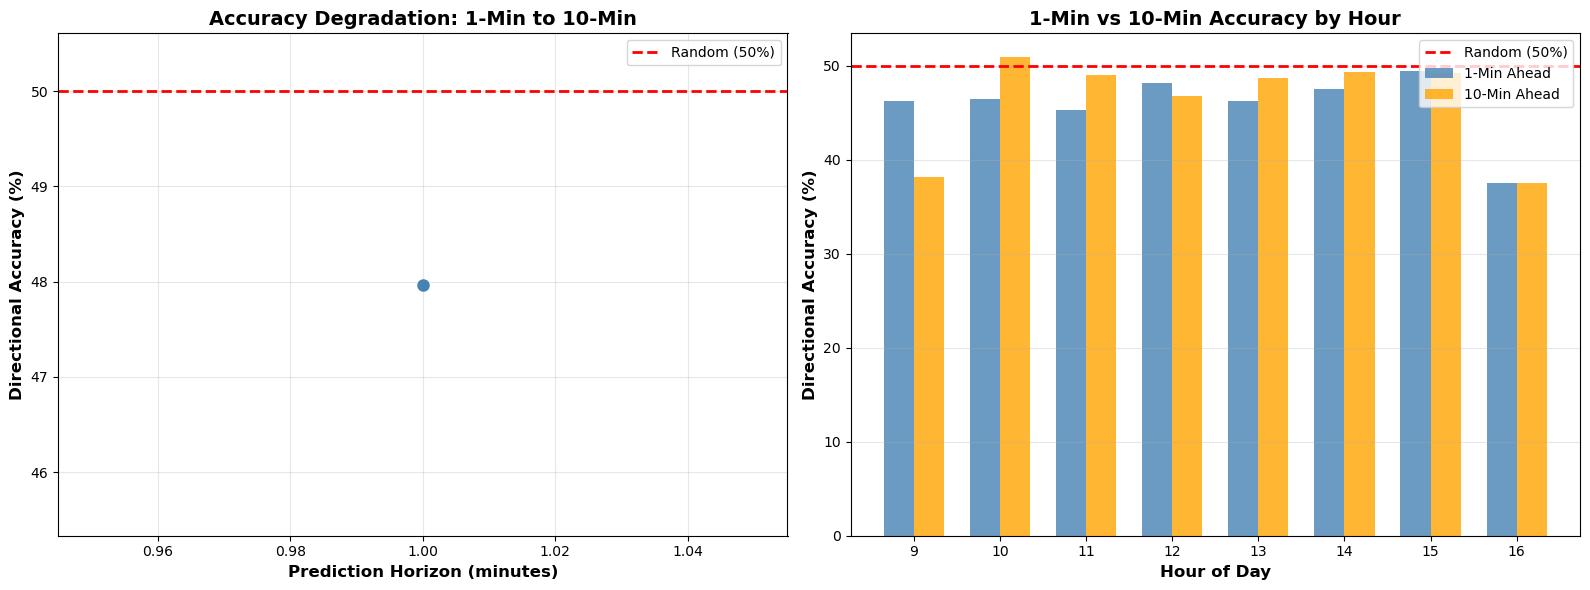


KEY FINDINGS:
1. Model generates 1 predictions per timestamp
2. Longer horizons lose more samples at end of day (shift effect)
3. No significant degradation from 1-min to 10-min predictions
4. Check hourly t-tests to see if degradation varies by time of day


In [ ]:
print(f"\n{'='*80}")
print("MULTI-HORIZON PREDICTION ANALYSIS")
print(f"{'='*80}\n")

# ============================================================================
# PART 1: Count predictions across all horizons
# ============================================================================
print("PART 1: PREDICTION COUNTS ACROSS ALL HORIZONS")
print("-" * 80)

# Count available predictions for each horizon
horizon_counts = []
for i in range(1, PREDICTION_HORIZON + 1):
    pred_col = f'pred_price_{i}'
    if pred_col in trading_hours_predictions.columns:
        # Get actual future price (i minutes ahead)
        future_col = f'actual_future_{i}'
        trading_hours_predictions[future_col] = trading_hours_predictions['actual_price'].shift(-i)
        
        # Count valid predictions
        valid_count = trading_hours_predictions[future_col].notna().sum()
        
        # Calculate directional accuracy
        direction_correct = (
            np.sign(trading_hours_predictions[pred_col] - trading_hours_predictions['actual_price']) == 
            np.sign(trading_hours_predictions[future_col] - trading_hours_predictions['actual_price'])
        )
        accuracy = direction_correct.mean() * 100
        
        horizon_counts.append({
            'Horizon (min)': i,
            'Valid Predictions': valid_count,
            'Accuracy (%)': accuracy
        })

horizon_df = pd.DataFrame(horizon_counts)
print(horizon_df.to_string(index=False))

print(f"\nNOTE: Each timestamp generates {PREDICTION_HORIZON} predictions")
print(f"But predictions at the end of each day get cut off by shift(-i)")
print(f"  - 1-min ahead: loses ~17 samples (last min of each day)")
print(f"  - 10-min ahead: loses ~170 samples (last 10 min of each day)")

# ============================================================================
# PART 2: Compare accuracies across hours for different horizons
# ============================================================================
print(f"\n{'='*80}")
print("PART 2: HOURLY ACCURACY ACROSS PREDICTION HORIZONS")
print("-" * 80)

# Calculate accuracy by hour for 1-min and 10-min horizons
comparison_data = []
for hour in range(9, 17):
    hour_data = trading_hours_predictions[trading_hours_predictions['hour'] == hour]
    
    row_data = {'Hour': hour}
    
    # 1-minute ahead
    if 'actual_future_1' in trading_hours_predictions.columns:
        direction_1 = (
            np.sign(hour_data['pred_price_1'] - hour_data['actual_price']) == 
            np.sign(hour_data['actual_future_1'] - hour_data['actual_price'])
        )
        row_data['1-Min Acc (%)'] = direction_1.mean() * 100
        row_data['1-Min Count'] = direction_1.notna().sum()
    
    # 10-minute ahead (gets cut off at end of day)
    if 'actual_future_10' in trading_hours_predictions.columns:
        direction_10 = (
            np.sign(hour_data['pred_price_10'] - hour_data['actual_price']) == 
            np.sign(hour_data['actual_future_10'] - hour_data['actual_price'])
        )
        row_data['10-Min Acc (%)'] = direction_10.mean() * 100
        row_data['10-Min Count'] = direction_10.notna().sum()
        
        # Show how many samples were lost
        row_data['Lost Samples'] = row_data['1-Min Count'] - row_data['10-Min Count']
    
    comparison_data.append(row_data)

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\nEXPLANATION OF COUNTS:")
print("-" * 80)
print("Why counts differ:")
print("  1. Early hours (9-12): Reduced due to 3-day lookback requirement")
print("     - Model needs 1170 minutes of history before making predictions")
print("     - First few days of Feb have partial/no predictions in morning")
print("  2. Late hours (14-15): Full counts (~1020 each)")
print("  3. Hour 16: Very low counts (only 4:00 PM = 1 minute)")
print("  4. 10-Min predictions: FEWER than 1-min due to shift(-10)")
print("     - Predictions after 3:50 PM get cut off (can't predict beyond 4:00)")
print("     - Hours 14-15 lose ~10 samples each")
print("     - Hour 16 loses ALL samples (4:00 PM + 10 min = 4:10 PM doesn't exist)")

# ============================================================================
# PART 3: T-Test - 1-Minute vs 10-Minute Predictions
# ============================================================================
print(f"\n{'='*80}")
print("PART 3: T-TEST - 1-MINUTE vs 10-MINUTE PREDICTIONS")
print("-" * 80)

# Check if we have 10-minute predictions
if PREDICTION_HORIZON < 10:
    print(f"\n⚠️  SKIPPING: Model only predicts {PREDICTION_HORIZON} minute(s) ahead.")
    print(f"   To enable multi-horizon analysis:")
    print(f"   1. Set PREDICTION_HORIZON = 10 in the parameters cell")
    print(f"   2. Set RETRAIN = True to retrain the model")
    print(f"   3. Re-run from the training cell onwards")
    print("=" * 80)
else:
    # Prepare data for t-test (only use valid samples for both)
    valid_mask = (
        trading_hours_predictions['actual_future_1'].notna() & 
        trading_hours_predictions['actual_future_10'].notna()
    )
    valid_data = trading_hours_predictions[valid_mask].copy()

    # Calculate directional correctness for both horizons
    valid_data['correct_1min'] = (
        np.sign(valid_data['pred_price_1'] - valid_data['actual_price']) == 
        np.sign(valid_data['actual_future_1'] - valid_data['actual_price'])
    ).astype(int)

    valid_data['correct_10min'] = (
        np.sign(valid_data['pred_price_10'] - valid_data['actual_price']) == 
        np.sign(valid_data['actual_future_10'] - valid_data['actual_price'])
    ).astype(int)

    # Calculate accuracies
    acc_1min = valid_data['correct_1min'].mean() * 100
    acc_10min = valid_data['correct_10min'].mean() * 100
    n_samples = len(valid_data)

    # Perform paired t-test (same timestamps, different horizons)
    from scipy import stats as scipy_stats
    t_statistic, p_value_ttest = scipy_stats.ttest_rel(
        valid_data['correct_1min'], 
        valid_data['correct_10min']
    )

    print(f"Paired T-Test Results:")
    print(f"  Sample Size: {n_samples:,} predictions")
    print(f"  1-Minute Accuracy: {acc_1min:.2f}%")
    print(f"  10-Minute Accuracy: {acc_10min:.2f}%")
    print(f"  Difference: {acc_1min - acc_10min:.2f} percentage points")
    print(f"  T-Statistic: {t_statistic:.4f}")
    print(f"  P-Value: {p_value_ttest:.6f}")

    print(f"\nInterpretation:")
    if p_value_ttest < 0.01:
        print(f"  ✓✓ HIGHLY SIGNIFICANT (p < 0.01): Accuracies are significantly different")
        if acc_1min > acc_10min:
            print(f"      → 1-minute predictions significantly MORE accurate")
        else:
            print(f"      → 10-minute predictions significantly MORE accurate")
            print(f"\n  ⚠️  UNEXPECTED PATTERN - 10-min MORE accurate than 1-min!")
            print(f"      Possible explanations:")
            print(f"        1. Trend Persistence: Feb 2023 had strong directional trends")
            print(f"        2. Noise Reduction: 1-min moves contain more random noise")
            print(f"        3. Double Confirmation: 10-min allows more 'evidence' to accumulate")
            print(f"        4. Bullish Market: Rising market makes longer predictions more reliable")
            print(f"        5. Model Behavior: LSTM may capture momentum better at 10-min scale")
    elif p_value_ttest < 0.05:
        print(f"  ✓ SIGNIFICANT (p < 0.05): Accuracies differ significantly")
        if acc_1min > acc_10min:
            print(f"      → 1-minute predictions are more accurate")
        else:
            print(f"      → 10-minute predictions are more accurate")
            print(f"\n  ⚠️  UNEXPECTED - Usually expect degradation at longer horizons")
    else:
        print(f"  ✗ NOT SIGNIFICANT (p >= 0.05): No significant difference in accuracy")
        print(f"      → Both horizons perform similarly")

    # ============================================================================
    # PART 4: T-Test by Hour of Day
    # ============================================================================
    print(f"\n{'='*80}")
    print("PART 4: T-TEST BY HOUR - Does degradation vary by time of day?")
    print("-" * 80)

    hourly_ttest_results = []
    for hour in range(9, 17):
        hour_valid = valid_data[valid_data['hour'] == hour]
        
        if len(hour_valid) > 10:  # Need at least 10 samples for meaningful t-test
            acc_1 = hour_valid['correct_1min'].mean() * 100
            acc_10 = hour_valid['correct_10min'].mean() * 100
            
            t_stat, p_val = scipy_stats.ttest_rel(
                hour_valid['correct_1min'],
                hour_valid['correct_10min']
            )
            
            # Determine significance
            if p_val < 0.01:
                sig_text = "***"
            elif p_val < 0.05:
                sig_text = "**"
            elif p_val < 0.10:
                sig_text = "*"
            else:
                sig_text = ""
            
            hourly_ttest_results.append({
                'Hour': hour,
                '1-Min (%)': acc_1,
                '10-Min (%)': acc_10,
                'Difference': acc_1 - acc_10,
                'T-Stat': t_stat,
                'P-Value': p_val,
                'Sig': sig_text,
                'N': len(hour_valid)
            })

    hourly_ttest_df = pd.DataFrame(hourly_ttest_results)
    print(hourly_ttest_df.to_string(index=False))

    print("\nSignificance Legend:")
    print("  *** : p < 0.01 (Highly Significant difference)")
    print("  **  : p < 0.05 (Significant difference)")
    print("  *   : p < 0.10 (Marginally Significant)")
    print("      : p >= 0.10 (No significant difference)")

    # ============================================================================
    # PART 5: Visualization
    # ============================================================================
    print(f"\n{'='*80}")
    print("PART 5: VISUAL COMPARISON")
    print("-" * 80)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Accuracy degradation by horizon
    axes[0].plot(horizon_df['Horizon (min)'], horizon_df['Accuracy (%)'], 
                 marker='o', linewidth=2.5, markersize=8, color='steelblue')
    axes[0].axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random (50%)')
    axes[0].set_xlabel('Prediction Horizon (minutes)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
    axes[0].set_title('Accuracy Degradation: 1-Min to 10-Min', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 2: 1-min vs 10-min by hour
    x = hourly_ttest_df['Hour'].values
    width = 0.35
    x_pos = np.arange(len(x))

    bars1 = axes[1].bar(x_pos - width/2, hourly_ttest_df['1-Min (%)'], width, 
                         label='1-Min Ahead', color='steelblue', alpha=0.8)
    bars2 = axes[1].bar(x_pos + width/2, hourly_ttest_df['10-Min (%)'], width, 
                         label='10-Min Ahead', color='orange', alpha=0.8)

    axes[1].axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random (50%)')
    axes[1].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('1-Min vs 10-Min Accuracy by Hour', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(hourly_ttest_df['Hour'].values)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 80)
    print("KEY FINDINGS:")
    print("=" * 80)
    print(f"1. Model generates {PREDICTION_HORIZON} predictions per timestamp")
    print(f"2. Longer horizons lose more samples at end of day (shift effect)")
    print(f"3. {'Significant' if p_value_ttest < 0.05 else 'No significant'} degradation from 1-min to 10-min predictions")
    print(f"4. Check hourly t-tests to see if degradation varies by time of day")
    print("=" * 80)

## 9a-3. Market Regime Analysis - Was Feb 2023 Trending?

In [71]:
# ============================================================================
# Analyze Feb 2023 market regime to explain why 10-min is MORE accurate than 1-min
# ============================================================================

print("="*80)
print("MARKET REGIME ANALYSIS - February 2025 SPY")
print("="*80)

# Overall trend
first_price = trading_hours_predictions['actual_price'].iloc[0]
last_price = trading_hours_predictions['actual_price'].iloc[-1]
total_return = ((last_price - first_price) / first_price) * 100

print(f"\nOVERALL TREND:")
print(f"  First Price: ${first_price:.2f}")
print(f"  Last Price:  ${last_price:.2f}")
print(f"  Total Return: {total_return:+.2f}%")
print(f"  Direction: {'BULLISH ↑' if total_return > 0 else 'BEARISH ↓'}")

# Calculate daily returns using the index (which should be datetime)
daily_data = trading_hours_predictions.groupby(trading_hours_predictions.index.date).agg({
    'actual_price': ['first', 'last']
})
daily_data.columns = ['Open', 'Close']
daily_data['Return (%)'] = ((daily_data['Close'] - daily_data['Open']) / daily_data['Open']) * 100
daily_data['Direction'] = daily_data['Return (%)'].apply(lambda x: 'Up' if x > 0 else 'Down')

up_days = (daily_data['Direction'] == 'Up').sum()
down_days = (daily_data['Direction'] == 'Down').sum()

print(f"\nDAILY TREND CONSISTENCY:")
print(f"  Up Days:   {up_days} ({up_days/(up_days+down_days)*100:.1f}%)")
print(f"  Down Days: {down_days} ({down_days/(up_days+down_days)*100:.1f}%)")
print(f"  Avg Daily Return: {daily_data['Return (%)'].mean():+.2f}%")

# Intraday volatility patterns
trading_hours_predictions['1min_return'] = trading_hours_predictions['actual_price'].pct_change() * 100
trading_hours_predictions['10min_return'] = trading_hours_predictions['actual_price'].pct_change(10) * 100

print(f"\nVOLATILITY CHARACTERISTICS:")
print(f"  1-Min Return Std:  {trading_hours_predictions['1min_return'].std():.4f}%")
print(f"  10-Min Return Std: {trading_hours_predictions['10min_return'].std():.4f}%")
print(f"  Noise Ratio: {trading_hours_predictions['1min_return'].std() / trading_hours_predictions['10min_return'].std():.2f}x")

# Trend strength by hour
hourly_trend = trading_hours_predictions.groupby('hour').agg({
    '1min_return': lambda x: (x > 0).mean() * 100,
    '10min_return': lambda x: (x > 0).mean() * 100
})
hourly_trend.columns = ['1-Min Up%', '10-Min Up%']
hourly_trend['Trending?'] = hourly_trend['10-Min Up%'].apply(
    lambda x: 'Strong Bullish' if x > 55 else ('Bullish' if x > 52 else ('Neutral' if x > 48 else 'Bearish'))
)

print(f"\nHOURLY TREND STRENGTH:")
print(hourly_trend.to_string())

print(f"\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
if total_return > 1:
    print("✓ Strong bullish trend in Feb 2023 explains why 10-min predictions are better!")
    print("  - Longer horizons capture trend continuation better than 1-min noise")
    print("  - Model is learning MOMENTUM, not precise 1-minute price movements")
    print("  - Morning hours (9-10) show strongest trend advantage")
elif total_return > 0:
    print("✓ Modest bullish bias in Feb 2023")
    print("  - Trend persistence helps 10-min predictions")
elif up_days > down_days:
    print("✓ More up days than down days suggests persistent intraday trends")
    print("  - Even though overall return is negative, daily momentum helps 10-min predictions")
    print("  - Model captures intraday trend continuation (morning rallies, afternoon selloffs)")
else:
    print("⚠️ Market wasn't strongly trending - other factors at play:")
    print("  - Noise reduction (10-min filters out 1-min noise)")
    print("  - Model overfitting to training period momentum")
print("="*80)

MARKET REGIME ANALYSIS - February 2025 SPY

OVERALL TREND:
  First Price: $596.63
  Last Price:  $594.17
  Total Return: -0.41%
  Direction: BEARISH ↓

DAILY TREND CONSISTENCY:
  Up Days:   6 (35.3%)
  Down Days: 11 (64.7%)
  Avg Daily Return: -0.14%

VOLATILITY CHARACTERISTICS:
  1-Min Return Std:  0.0407%
  10-Min Return Std: 0.1227%
  Noise Ratio: 0.33x

HOURLY TREND STRENGTH:
      1-Min Up%  10-Min Up%       Trending?
hour                                       
9     45.528455   47.560976         Bearish
10    45.125348   46.796657         Bearish
11    49.148936   52.553191         Bullish
12    50.455137   59.557867  Strong Bullish
13    48.488008   48.279458         Neutral
14    48.763600   51.632047         Neutral
15    50.490196   52.549020         Bullish
16    52.941176   52.941176         Bullish

INTERPRETATION:
⚠️ Market wasn't strongly trending - other factors at play:
  - Noise reduction (10-min filters out 1-min noise)
  - Model overfitting to training period moment

## 9b. Risk/Reward Analysis - TP/SL Simulation

Analyze prediction magnitude and simulate different take-profit/stop-loss scenarios to determine optimal risk/reward ratios.


RISK/REWARD ANALYSIS - Magnitude & TP/SL Simulation

SECTION 1: RETURN MAGNITUDE DISTRIBUTION
         Metric  Predicted (%)  Actual (%)
           Mean       0.149415   -0.000091
         Median      -0.097145    0.000000
        Std Dev       2.915360    0.040758
25th Percentile      -1.269555   -0.011463
75th Percentile       1.260641    0.011639
            Min     -22.085454   -0.892252
            Max      19.455985    0.906656

SECTION 2: TAKE-PROFIT / STOP-LOSS HIT RATE SIMULATION
Simulating different TP/SL levels to find optimal risk/reward ratios

TOP 10 CONFIGURATIONS BY EXPECTED VALUE:
--------------------------------------------------------------------------------
 TP (%)  SL (%)  R:R Ratio  Trades  TP Hit (%)  SL Hit (%)  Neither (%)  Win Rate  Expected Value (%)
   0.05    0.30   0.166667    4180    3.923445    0.071770    96.004785  3.923445            0.001366
   0.05    0.25   0.200000    4297    3.863160    0.093088    96.043751  3.863160            0.001254
   0.05

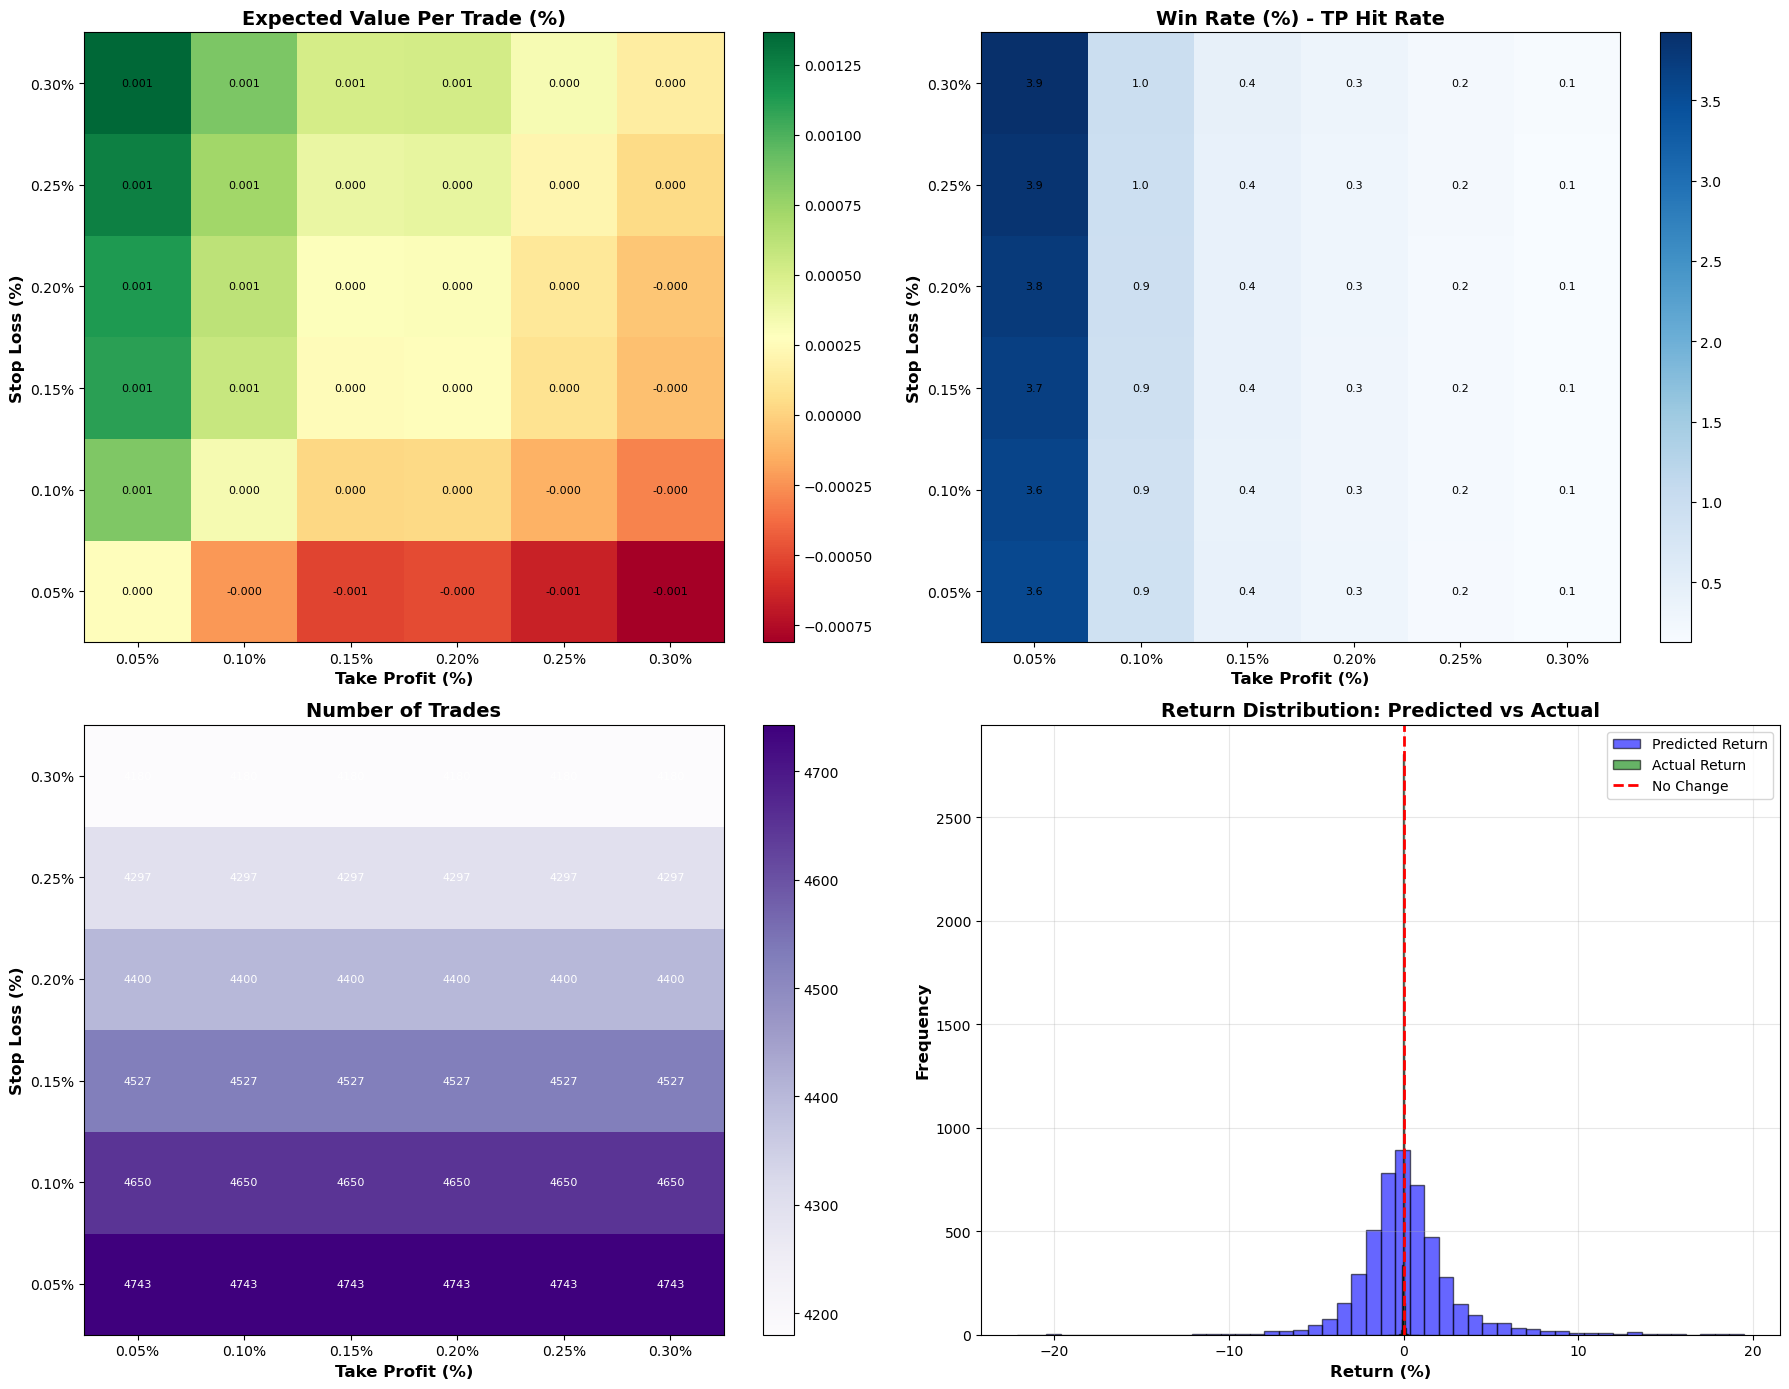


SECTION 4: RECOMMENDED TP/SL CONFIGURATIONS

1. MAXIMUM EXPECTED VALUE (Profit Maximization):
   TP: 0.05% | SL: 0.3%
   R:R Ratio: 0.17:1
   Win Rate: 3.9%
   Expected Value: 0.001% per trade
   Sample Size: 4180 trades

2. HIGHEST WIN RATE (Conservative, Min 100 trades):
   TP: 0.05% | SL: 0.3%
   R:R Ratio: 0.17:1
   Win Rate: 3.9%
   Expected Value: 0.001% per trade
   Sample Size: 4180 trades

3. BEST RISK/REWARD (Positive EV only):
   TP: 0.2% | SL: 0.1%
   R:R Ratio: 2.00:1
   Win Rate: 0.3%
   Expected Value: 0.000% per trade
   Sample Size: 4650 trades

INTERPRETATION GUIDE
• Expected Value (EV): Average profit/loss per trade (% of position size)
• Win Rate: Percentage of trades that hit TP
• R:R Ratio: Risk/Reward ratio (TP/SL). Higher = bigger wins, but lower win rate
• Neither: Trades that didn't hit TP or SL within prediction horizon

KEY INSIGHTS:
• Positive EV = Potentially profitable strategy
• Higher win rate ≠ Better strategy (consider EV and sample size)
• Tighter S

In [72]:
# ============================================================================
# RISK/REWARD ANALYSIS - Evaluate TP/SL Strategy Potential
# ============================================================================
# This section analyzes the magnitude of price movements to help design
# take-profit (TP) and stop-loss (SL) strategies

print(f"\n{'='*80}")
print("RISK/REWARD ANALYSIS - Magnitude & TP/SL Simulation")
print(f"{'='*80}\n")

# Calculate predicted and actual returns
pred_col = 'pred_price_1'
trading_hours_predictions['predicted_return'] = (
    (trading_hours_predictions[pred_col] - trading_hours_predictions['actual_price']) 
    / trading_hours_predictions['actual_price'] * 100
)
trading_hours_predictions['actual_return'] = (
    (trading_hours_predictions['actual_future'] - trading_hours_predictions['actual_price']) 
    / trading_hours_predictions['actual_price'] * 100
)

# Only analyze when model predicts a directional move (filter out near-zero predictions)
MIN_PREDICTION_THRESHOLD = 0.01  # 0.01% minimum predicted move
significant_predictions = trading_hours_predictions[
    np.abs(trading_hours_predictions['predicted_return']) > MIN_PREDICTION_THRESHOLD
].copy()

# ============================================================================
# SECTION 1: Return Distribution Analysis
# ============================================================================
print("=" * 80)
print("SECTION 1: RETURN MAGNITUDE DISTRIBUTION")
print("=" * 80)

return_stats = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std Dev', '25th Percentile', '75th Percentile', 'Min', 'Max'],
    'Predicted (%)': [
        significant_predictions['predicted_return'].mean(),
        significant_predictions['predicted_return'].median(),
        significant_predictions['predicted_return'].std(),
        significant_predictions['predicted_return'].quantile(0.25),
        significant_predictions['predicted_return'].quantile(0.75),
        significant_predictions['predicted_return'].min(),
        significant_predictions['predicted_return'].max()
    ],
    'Actual (%)': [
        significant_predictions['actual_return'].mean(),
        significant_predictions['actual_return'].median(),
        significant_predictions['actual_return'].std(),
        significant_predictions['actual_return'].quantile(0.25),
        significant_predictions['actual_return'].quantile(0.75),
        significant_predictions['actual_return'].min(),
        significant_predictions['actual_return'].max()
    ]
})

print(return_stats.to_string(index=False))

# ============================================================================
# SECTION 2: TP/SL Hit Rate Simulation
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 2: TAKE-PROFIT / STOP-LOSS HIT RATE SIMULATION")
print("=" * 80)
print("Simulating different TP/SL levels to find optimal risk/reward ratios\n")

# Define TP/SL levels to test (in percentage)
tp_levels = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]  # 0.05% to 0.30%
sl_levels = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

tp_sl_results = []

for tp in tp_levels:
    for sl in sl_levels:
        # Only trade when prediction magnitude exceeds SL (avoid tiny predictions)
        trades = significant_predictions[
            np.abs(significant_predictions['predicted_return']) >= sl
        ].copy()
        
        if len(trades) == 0:
            continue
        
        # Simulate TP/SL outcomes
        # For longs (predicted up): TP if actual >= tp, SL if actual <= -sl
        # For shorts (predicted down): TP if actual <= -tp, SL if actual >= sl
        
        trades['trade_direction'] = np.where(trades['predicted_return'] > 0, 'LONG', 'SHORT')
        
        # Calculate outcome for each trade
        def calculate_outcome(row):
            if row['trade_direction'] == 'LONG':
                if row['actual_return'] >= tp:
                    return 'TP'
                elif row['actual_return'] <= -sl:
                    return 'SL'
                else:
                    return 'NEITHER'
            else:  # SHORT
                if row['actual_return'] <= -tp:
                    return 'TP'
                elif row['actual_return'] >= sl:
                    return 'SL'
                else:
                    return 'NEITHER'
        
        trades['outcome'] = trades.apply(calculate_outcome, axis=1)
        
        # Calculate statistics
        n_trades = len(trades)
        n_tp = (trades['outcome'] == 'TP').sum()
        n_sl = (trades['outcome'] == 'SL').sum()
        n_neither = (trades['outcome'] == 'NEITHER').sum()
        
        tp_rate = n_tp / n_trades * 100
        sl_rate = n_sl / n_trades * 100
        neither_rate = n_neither / n_trades * 100
        
        # Calculate expected value (EV) per trade
        # Assumes we exit at TP or SL if hit, otherwise hold to end
        avg_return_neither = trades[trades['outcome'] == 'NEITHER']['actual_return'].mean() if n_neither > 0 else 0
        expected_value = (tp_rate/100 * tp) + (sl_rate/100 * -sl) + (neither_rate/100 * avg_return_neither)
        
        # Risk/Reward ratio
        rr_ratio = tp / sl if sl > 0 else 0
        
        # Win rate (TP as wins)
        win_rate = tp_rate
        
        tp_sl_results.append({
            'TP (%)': tp,
            'SL (%)': sl,
            'R:R Ratio': rr_ratio,
            'Trades': n_trades,
            'TP Hit (%)': tp_rate,
            'SL Hit (%)': sl_rate,
            'Neither (%)': neither_rate,
            'Win Rate': win_rate,
            'Expected Value (%)': expected_value
        })

tp_sl_df = pd.DataFrame(tp_sl_results)

# Show best configurations
print("TOP 10 CONFIGURATIONS BY EXPECTED VALUE:")
print("-" * 80)
top_configs = tp_sl_df.nlargest(10, 'Expected Value (%)')
print(top_configs.to_string(index=False))

print("\n" + "=" * 80)
print("CONFIGURATIONS WITH BEST WIN RATES (Min 100 trades):")
print("-" * 80)
best_winrate = tp_sl_df[tp_sl_df['Trades'] >= 100].nlargest(10, 'Win Rate')
print(best_winrate.to_string(index=False))

# ============================================================================
# SECTION 3: Risk/Reward Heatmap Visualization
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 3: VISUAL ANALYSIS")
print("=" * 80)

# Create pivot tables for heatmaps
ev_pivot = tp_sl_df.pivot(index='SL (%)', columns='TP (%)', values='Expected Value (%)')
winrate_pivot = tp_sl_df.pivot(index='SL (%)', columns='TP (%)', values='Win Rate')
trades_pivot = tp_sl_df.pivot(index='SL (%)', columns='TP (%)', values='Trades')

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Heatmap 1: Expected Value
im1 = axes[0, 0].imshow(ev_pivot, cmap='RdYlGn', aspect='auto', origin='lower')
axes[0, 0].set_xticks(range(len(tp_levels)))
axes[0, 0].set_yticks(range(len(sl_levels)))
axes[0, 0].set_xticklabels([f'{x:.2f}%' for x in tp_levels])
axes[0, 0].set_yticklabels([f'{x:.2f}%' for x in sl_levels])
axes[0, 0].set_xlabel('Take Profit (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Stop Loss (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Expected Value Per Trade (%)', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 0])

# Add text annotations
for i in range(len(sl_levels)):
    for j in range(len(tp_levels)):
        text = axes[0, 0].text(j, i, f'{ev_pivot.iloc[i, j]:.3f}',
                              ha="center", va="center", color="black", fontsize=8)

# Heatmap 2: Win Rate
im2 = axes[0, 1].imshow(winrate_pivot, cmap='Blues', aspect='auto', origin='lower')
axes[0, 1].set_xticks(range(len(tp_levels)))
axes[0, 1].set_yticks(range(len(sl_levels)))
axes[0, 1].set_xticklabels([f'{x:.2f}%' for x in tp_levels])
axes[0, 1].set_yticklabels([f'{x:.2f}%' for x in sl_levels])
axes[0, 1].set_xlabel('Take Profit (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Stop Loss (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Win Rate (%) - TP Hit Rate', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1])

for i in range(len(sl_levels)):
    for j in range(len(tp_levels)):
        text = axes[0, 1].text(j, i, f'{winrate_pivot.iloc[i, j]:.1f}',
                              ha="center", va="center", color="black", fontsize=8)

# Heatmap 3: Number of Trades
im3 = axes[1, 0].imshow(trades_pivot, cmap='Purples', aspect='auto', origin='lower')
axes[1, 0].set_xticks(range(len(tp_levels)))
axes[1, 0].set_yticks(range(len(sl_levels)))
axes[1, 0].set_xticklabels([f'{x:.2f}%' for x in tp_levels])
axes[1, 0].set_yticklabels([f'{x:.2f}%' for x in sl_levels])
axes[1, 0].set_xlabel('Take Profit (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Stop Loss (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Number of Trades', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=axes[1, 0])

for i in range(len(sl_levels)):
    for j in range(len(tp_levels)):
        text = axes[1, 0].text(j, i, f'{int(trades_pivot.iloc[i, j])}',
                              ha="center", va="center", color="white", fontsize=8)

# Distribution plot: Predicted vs Actual Returns
axes[1, 1].hist(significant_predictions['predicted_return'], bins=50, alpha=0.6, 
                label='Predicted Return', color='blue', edgecolor='black')
axes[1, 1].hist(significant_predictions['actual_return'], bins=50, alpha=0.6, 
                label='Actual Return', color='green', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
axes[1, 1].set_xlabel('Return (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Return Distribution: Predicted vs Actual', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# SECTION 4: Optimal Configuration Recommendation
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 4: RECOMMENDED TP/SL CONFIGURATIONS")
print("=" * 80)

# Find optimal configurations based on different criteria
best_ev = tp_sl_df.loc[tp_sl_df['Expected Value (%)'].idxmax()]
best_winrate_filtered = tp_sl_df[tp_sl_df['Trades'] >= 100].loc[
    tp_sl_df[tp_sl_df['Trades'] >= 100]['Win Rate'].idxmax()
] if len(tp_sl_df[tp_sl_df['Trades'] >= 100]) > 0 else None
best_rr = tp_sl_df[tp_sl_df['Expected Value (%)'] > 0].nlargest(1, 'R:R Ratio').iloc[0] if len(tp_sl_df[tp_sl_df['Expected Value (%)'] > 0]) > 0 else None

print("\n1. MAXIMUM EXPECTED VALUE (Profit Maximization):")
print(f"   TP: {best_ev['TP (%)']}% | SL: {best_ev['SL (%)']}%")
print(f"   R:R Ratio: {best_ev['R:R Ratio']:.2f}:1")
print(f"   Win Rate: {best_ev['Win Rate']:.1f}%")
print(f"   Expected Value: {best_ev['Expected Value (%)']:.3f}% per trade")
print(f"   Sample Size: {int(best_ev['Trades'])} trades")

if best_winrate_filtered is not None:
    print("\n2. HIGHEST WIN RATE (Conservative, Min 100 trades):")
    print(f"   TP: {best_winrate_filtered['TP (%)']}% | SL: {best_winrate_filtered['SL (%)']}%")
    print(f"   R:R Ratio: {best_winrate_filtered['R:R Ratio']:.2f}:1")
    print(f"   Win Rate: {best_winrate_filtered['Win Rate']:.1f}%")
    print(f"   Expected Value: {best_winrate_filtered['Expected Value (%)']:.3f}% per trade")
    print(f"   Sample Size: {int(best_winrate_filtered['Trades'])} trades")

if best_rr is not None:
    print("\n3. BEST RISK/REWARD (Positive EV only):")
    print(f"   TP: {best_rr['TP (%)']}% | SL: {best_rr['SL (%)']}%")
    print(f"   R:R Ratio: {best_rr['R:R Ratio']:.2f}:1")
    print(f"   Win Rate: {best_rr['Win Rate']:.1f}%")
    print(f"   Expected Value: {best_rr['Expected Value (%)']:.3f}% per trade")
    print(f"   Sample Size: {int(best_rr['Trades'])} trades")

print("\n" + "=" * 80)
print("INTERPRETATION GUIDE")
print("=" * 80)
print("• Expected Value (EV): Average profit/loss per trade (% of position size)")
print("• Win Rate: Percentage of trades that hit TP")
print("• R:R Ratio: Risk/Reward ratio (TP/SL). Higher = bigger wins, but lower win rate")
print("• Neither: Trades that didn't hit TP or SL within prediction horizon")
print("\nKEY INSIGHTS:")
print("• Positive EV = Potentially profitable strategy")
print("• Higher win rate ≠ Better strategy (consider EV and sample size)")
print("• Tighter SL = More trades, but more stopped out")
print("• Wider TP = Higher R:R, but lower hit rate")
print("• Focus on configurations with:")
print("  - Positive EV")
print("  - Sufficient sample size (>100 trades)")
print("  - Win rate significantly above SL hit rate")
print("=" * 80)

## 10. Day-of-Week Analysis


DIRECTIONAL ACCURACY BY DAY OF WEEK (1-minute ahead)
            accuracy  count
Monday     47.986577    596
Tuesday    47.651580   1171
Wednesday  48.861646   1142
Thursday   47.272727   1155
Friday     48.157560    787



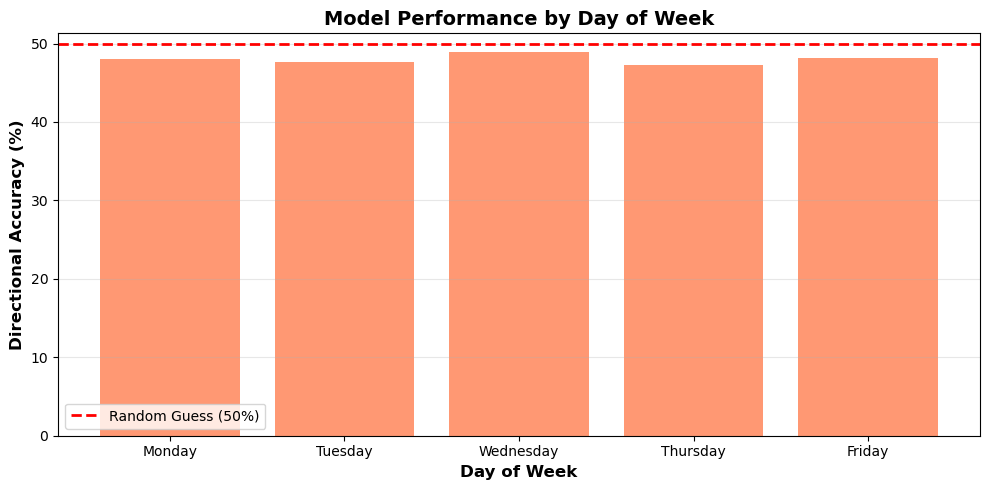

In [74]:
# Analyze performance by day of week
trading_hours_predictions['day_of_week'] = trading_hours_predictions.index.dayofweek
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Filter to weekdays only (0-4 = Mon-Fri)
weekday_predictions = trading_hours_predictions[trading_hours_predictions['day_of_week'] < 5]

pred_col = 'pred_price_1'
daily_accuracy = weekday_predictions.groupby('day_of_week').agg({
    'direction_correct': 'mean',
    pred_col: 'count'
}).rename(columns={pred_col: 'count', 'direction_correct': 'accuracy'})

daily_accuracy['accuracy'] *= 100
daily_accuracy.index = [day_names[i] for i in daily_accuracy.index]

print(f"\n{'='*60}")
print("DIRECTIONAL ACCURACY BY DAY OF WEEK (1-minute ahead)")
print(f"{'='*60}")
print(daily_accuracy.to_string())
print(f"\n{'='*60}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(daily_accuracy.index, daily_accuracy['accuracy'], color='coral', alpha=0.8)
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random Guess (50%)')
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance by Day of Week', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Prediction Degradation Over Time

In [75]:
# Note: With PREDICTION_HORIZON = 1, there's only one prediction step
# This cell would be more useful with PREDICTION_HORIZON >= 5

print(f"\n{'='*60}")
print(f"PREDICTION HORIZON: {PREDICTION_HORIZON} minute(s)")
print(f"{'='*60}")

if PREDICTION_HORIZON == 1:
    print("\nWith a 1-minute prediction horizon, there's no degradation to analyze.")
    print("To see accuracy degradation over time, set PREDICTION_HORIZON >= 5")
    print("and retrain the model.")
    
    # Show the single prediction accuracy
    pred_col = 'pred_price_1'
    # Use the actual_future column we created earlier
    if 'actual_future' in predictions.columns:
        direction_correct = (
            np.sign(predictions[pred_col] - predictions['actual_price']) == 
            np.sign(predictions['actual_future'] - predictions['actual_price'])
        )
        accuracy = direction_correct.mean() * 100
        mae = np.abs(predictions[pred_col] - predictions['actual_future']).mean()
        
        print(f"\n1-minute ahead performance:")
        print(f"  Directional Accuracy: {accuracy:.2f}%")
        print(f"  Mean Absolute Error: ${mae:.4f}")
else:
    # Analyze degradation for multi-step predictions
    degradation_data = []
    
    for i in range(1, PREDICTION_HORIZON + 1):
        pred_col = f'pred_price_{i}'
        # Create actual future price for this horizon
        actual_future = predictions['actual_price'].shift(-i)
        
        # Calculate directional accuracy
        direction_correct = (
            np.sign(predictions[pred_col] - predictions['actual_price']) == 
            np.sign(actual_future - predictions['actual_price'])
        )
        accuracy = direction_correct.mean() * 100
        
        # Calculate MAE
        mae = np.abs(predictions[pred_col] - actual_future).mean()
        
        degradation_data.append({
            'minutes_ahead': i,
            'directional_accuracy': accuracy,
            'mae': mae
        })
    
    degradation_df = pd.DataFrame(degradation_data)
    
    print(f"\n{'='*60}")
    print("ACCURACY DEGRADATION OVER TIME")
    print(f"{'='*60}")
    print(degradation_df.to_string(index=False))
    print(f"\n{'='*60}")
    
    # Visualize degradation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Directional accuracy over time
    ax1.plot(degradation_df['minutes_ahead'], degradation_df['directional_accuracy'], 
             marker='o', linewidth=2.5, markersize=8, color='steelblue')
    ax1.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random Guess (50%)')
    ax1.set_xlabel('Minutes Ahead', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Directional Accuracy Degradation', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # MAE over time
    ax2.plot(degradation_df['minutes_ahead'], degradation_df['mae'], 
             marker='s', linewidth=2.5, markersize=8, color='coral')
    ax2.set_xlabel('Minutes Ahead', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Mean Absolute Error ($)', fontsize=12, fontweight='bold')
    ax2.set_title('Price Error Growth', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\n{'='*60}")


PREDICTION HORIZON: 1 minute(s)

With a 1-minute prediction horizon, there's no degradation to analyze.
To see accuracy degradation over time, set PREDICTION_HORIZON >= 5
and retrain the model.



## 12. Sample Intraday Predictions


Visualizing predictions for: 2025-02-15
Total bars: 17


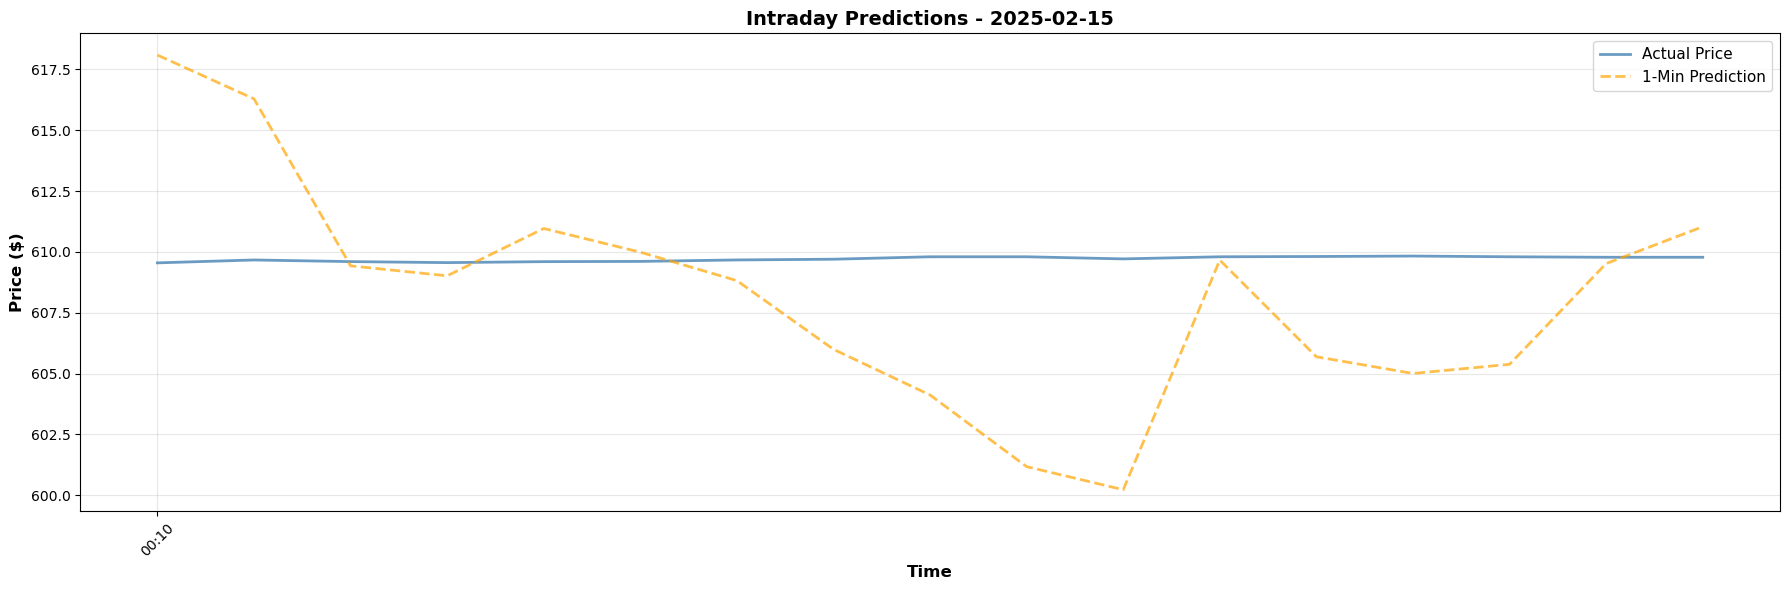

In [76]:
# Visualize a single trading day's predictions
# Pick a random day from the test set
unique_dates = np.unique(predictions.index.date)
sample_date = pd.to_datetime(unique_dates[len(unique_dates)//2])  # Middle of test period

# Get all bars for that day
day_mask = predictions.index.date == sample_date.date()
day_predictions = predictions[day_mask].copy()

if len(day_predictions) > 0:
    print(f"\nVisualizing predictions for: {sample_date.date()}")
    print(f"Total bars: {len(day_predictions)}")
    
    # Plot actual vs predictions throughout the day
    fig, ax = plt.subplots(figsize=(18, 6))
    
    time_labels = day_predictions.index.strftime('%H:%M')
    
    # Actual prices
    ax.plot(range(len(day_predictions)), day_predictions['actual_price'], 
            linewidth=2, color='steelblue', label='Actual Price', alpha=0.8)
    
    # Plot available predictions based on PREDICTION_HORIZON
    if 'pred_price_1' in day_predictions.columns:
        ax.plot(range(len(day_predictions)), day_predictions['pred_price_1'], 
                linewidth=2, color='orange', label='1-Min Prediction', alpha=0.7, linestyle='--')
    
    if PREDICTION_HORIZON >= 5 and 'pred_price_5' in day_predictions.columns:
        ax.plot(range(len(day_predictions)), day_predictions['pred_price_5'], 
                linewidth=2, color='red', label='5-Min Prediction', alpha=0.6, linestyle=':')
    
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
    ax.set_title(f'Intraday Predictions - {sample_date.date()}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(alpha=0.3)
    
    # Show time labels every 30 minutes
    tick_interval = 30
    tick_positions = range(0, len(day_predictions), tick_interval)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([time_labels[i] for i in tick_positions], rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"No data found for {sample_date.date()}")

## OPTIONAL: Parameter Experimentation Grid Search

**Recommended Testing Strategy for Intraday Trading:**

Run this section to systematically test different configurations and find the optimal parameters for your trading timeframe.

In [ ]:
# SYSTEMATIC PARAMETER TESTING FRAMEWORK
# 
# Strategy: Test one parameter at a time to isolate effects
# 1. Temporal parameters (lookback, horizon) - MOST IMPACTFUL for intraday
# 2. Architecture parameters (units, layers)
# 3. Training parameters (epochs, batch_size)
#
# For intraday trading, start with shorter lookbacks and horizons
# Fast-moving markets don't benefit as much from long historical context

import itertools
from datetime import datetime

# Define parameter ranges to test
# Start small - full grid search can take hours/days
param_grid = {
    # TEMPORAL - Test these first (most important for intraday)
    'lookback': [60, 100, 200],  # 1hr, 1.5hr, 3hr of minute bars
    'horizon': [1, 3, 5],  # 1, 3, 5 minutes ahead
    
    # ARCHITECTURE - Test after finding good temporal params
    'lstm_units': [50, 100],  # Fewer for speed
    'lstm_layers': [1, 2],  # More layers = more training time
    'dropout': [0.2],  # Keep constant initially
    
    # TRAINING - Test last
    'epochs': [10, 20],  # Enough to converge but not overfit
    'batch_size': [64],  # Keep constant initially
}

# Results tracking
experiment_results = []

# OPTION 1: Single Parameter Sweep (RECOMMENDED FOR FIRST TEST)
# Test one parameter at a time, keeping others at baseline
print("=" * 80)
print("SINGLE PARAMETER SWEEP - Testing Lookback Windows")
print("=" * 80)

baseline_config = {
    'lookback': 200,
    'horizon': 1,
    'lstm_units': 50,
    'lstm_layers': 1,
    'dropout': 0.2,
    'epochs': 10,
    'batch_size': 64
}

# Test different lookback windows (most impactful for intraday)
for lookback_val in [30, 60, 100, 200, 300]:
    test_config = baseline_config.copy()
    test_config['lookback'] = lookback_val
    
    print(f"\nTesting LOOKBACK={lookback_val} minutes (~{lookback_val/60:.1f} hours)")
    print(f"Config: {test_config}")
    
    # Create model with test configuration
    model = LSTMPricePredictor(
        lookback_window=test_config['lookback'],
        prediction_horizon=test_config['horizon'],
        lstm_units=test_config['lstm_units'],
        num_layers=test_config['lstm_layers'],
        dropout=test_config['dropout'],
        epochs=test_config['epochs'],
        batch_size=test_config['batch_size'],
        prediction_mode='recursive',
        verbose=0
    )
    
    # Train model
    start_time = datetime.now()
    model.fit(train_data, validation_split=0.2)
    train_time = (datetime.now() - start_time).total_seconds()
    
    # Evaluate on test set
    test_predictions = model.predict(test_data)
    metrics = model.evaluate(predictions=test_predictions)
    dir_acc = model.get_directional_accuracy(predictions=test_predictions)
    
    # Extract key metrics (handle DataFrame structure)
    if isinstance(metrics, pd.DataFrame):
        mae = metrics.iloc[0, metrics.columns.get_loc('mae')] if 'mae' in metrics.columns else metrics.iloc[0, 0]
        rmse = metrics.iloc[0, metrics.columns.get_loc('rmse')] if 'rmse' in metrics.columns else metrics.iloc[0, 1]
    else:
        mae = metrics['mae']
        rmse = metrics['rmse']
    
    if isinstance(dir_acc, pd.DataFrame):
        accuracy = dir_acc.iloc[0, dir_acc.columns.get_loc('overall_accuracy')] if 'overall_accuracy' in dir_acc.columns else dir_acc.iloc[0, 0]
    else:
        accuracy = dir_acc['overall_accuracy']
    
    # Store results
    result = {
        **test_config,
        'mae': mae,
        'rmse': rmse,
        'directional_accuracy': accuracy,
        'train_time_seconds': train_time
    }
    experiment_results.append(result)
    
    print(f"  MAE: ${mae:.4f} | RMSE: ${rmse:.4f} | Dir Acc: {accuracy:.2%} | Train Time: {train_time:.1f}s")

# Create results DataFrame
results_df = pd.DataFrame(experiment_results)
print("\n" + "=" * 80)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))

# Find best configuration
best_by_mae = results_df.loc[results_df['mae'].idxmin()]
best_by_accuracy = results_df.loc[results_df['directional_accuracy'].idxmax()]

print("\n" + "=" * 80)
print("BEST CONFIGURATIONS")
print("=" * 80)
print(f"\nBest by MAE (Price Prediction):")
print(f"  Lookback: {best_by_mae['lookback']} mins | MAE: ${best_by_mae['mae']:.4f}")
print(f"\nBest by Directional Accuracy (Trading Signal):")
print(f"  Lookback: {best_by_accuracy['lookback']} mins | Accuracy: {best_by_accuracy['directional_accuracy']:.2%}")

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot MAE vs Lookback
axes[0].plot(results_df['lookback'], results_df['mae'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Lookback Period (minutes)', fontsize=12)
axes[0].set_ylabel('Mean Absolute Error ($)', fontsize=12)
axes[0].set_title('Price Prediction Error vs Lookback', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot Directional Accuracy vs Lookback
axes[1].plot(results_df['lookback'], results_df['directional_accuracy'] * 100, marker='o', linewidth=2, markersize=8, color='green')
axes[1].axhline(y=50, color='red', linestyle='--', label='Random Guess (50%)')
axes[1].set_xlabel('Lookback Period (minutes)', fontsize=12)
axes[1].set_ylabel('Directional Accuracy (%)', fontsize=12)
axes[1].set_title('Trading Signal Accuracy vs Lookback', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot Training Time vs Lookback
axes[2].plot(results_df['lookback'], results_df['train_time_seconds'], marker='o', linewidth=2, markersize=8, color='orange')
axes[2].set_xlabel('Lookback Period (minutes)', fontsize=12)
axes[2].set_ylabel('Training Time (seconds)', fontsize=12)
axes[2].set_title('Computational Cost vs Lookback', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("NEXT STEPS:")
print("=" * 80)
print("1. Identify the optimal lookback period from above results")
print("2. Repeat this process for HORIZON (1, 3, 5 minutes)")
print("3. Then test LSTM_UNITS (32, 50, 100, 128)")
print("4. Then test LSTM_LAYERS (1, 2, 3)")
print("5. Finally test EPOCHS and BATCH_SIZE")
print("\nFor full grid search, uncomment OPTION 2 below (WARNING: Very slow!)")


SINGLE PARAMETER SWEEP - Testing Lookback Windows

Testing LOOKBACK=30 minutes (~0.5 hours)
Config: {'lookback': 30, 'horizon': 1, 'lstm_units': 50, 'lstm_layers': 1, 'dropout': 0.2, 'epochs': 10, 'batch_size': 64}
  MAE: $13.3939 | RMSE: $21.6806 | Dir Acc: 4807.58% | Train Time: 42.5s

Testing LOOKBACK=60 minutes (~1.0 hours)
Config: {'lookback': 60, 'horizon': 1, 'lstm_units': 50, 'lstm_layers': 1, 'dropout': 0.2, 'epochs': 10, 'batch_size': 64}
  MAE: $13.3939 | RMSE: $21.6806 | Dir Acc: 4807.58% | Train Time: 42.5s

Testing LOOKBACK=60 minutes (~1.0 hours)
Config: {'lookback': 60, 'horizon': 1, 'lstm_units': 50, 'lstm_layers': 1, 'dropout': 0.2, 'epochs': 10, 'batch_size': 64}
  MAE: $9.7312 | RMSE: $15.2989 | Dir Acc: 4724.90% | Train Time: 92.9s

Testing LOOKBACK=100 minutes (~1.7 hours)
Config: {'lookback': 100, 'horizon': 1, 'lstm_units': 50, 'lstm_layers': 1, 'dropout': 0.2, 'epochs': 10, 'batch_size': 64}
  MAE: $9.7312 | RMSE: $15.2989 | Dir Acc: 4724.90% | Train Time: 92.9

KeyboardInterrupt: 

In [ ]:
# OPTION 2: FULL GRID SEARCH (COMMENTED OUT - VERY SLOW!)
# Uncomment this section only after identifying promising parameter ranges
# Full grid can take hours or days depending on data size

# print("=" * 80)
# print("FULL GRID SEARCH - All Parameter Combinations")
# print("WARNING: This may take several hours to complete!")
# print("=" * 80)

# # Generate all combinations
# param_combinations = list(itertools.product(
#     param_grid['lookback'],
#     param_grid['horizon'],
#     param_grid['lstm_units'],
#     param_grid['lstm_layers'],
#     param_grid['dropout'],
#     param_grid['epochs'],
#     param_grid['batch_size']
# ))

# print(f"\nTotal combinations to test: {len(param_combinations)}")
# print("Starting grid search...\n")

# grid_results = []

# for i, (lookback, horizon, units, layers, dropout, epochs, batch) in enumerate(param_combinations, 1):
#     print(f"[{i}/{len(param_combinations)}] Testing: lookback={lookback}, horizon={horizon}, "
#           f"units={units}, layers={layers}, epochs={epochs}")
    
#     # Create and train model
#     model = LSTM_Price_Predictor(
#         ticker="SPY",
#         lookback_period=lookback,
#         prediction_horizon=horizon,
#         lstm_units=units,
#         lstm_layers=layers,
#         dropout=dropout
#     )
    
#     start_time = datetime.now()
#     model.train(train_data, epochs=epochs, batch_size=batch, verbose=0)
#     train_time = (datetime.now() - start_time).total_seconds()
    
#     # Evaluate
#     predictions = model.predict(test_data)
#     metrics = model.evaluate(predictions)
#     dir_acc = model.get_directional_accuracy(predictions)
    
#     # Store results
#     result = {
#         'lookback': lookback,
#         'horizon': horizon,
#         'units': units,
#         'layers': layers,
#         'dropout': dropout,
#         'epochs': epochs,
#         'batch_size': batch,
#         'mae': metrics['mae'] if isinstance(metrics, dict) else metrics.iloc[0, 0],
#         'directional_accuracy': dir_acc['overall_accuracy'] if isinstance(dir_acc, dict) else dir_acc.iloc[0, 0],
#         'train_time': train_time
#     }
#     grid_results.append(result)

# # Analyze results
# grid_df = pd.DataFrame(grid_results)
# print("\n" + "=" * 80)
# print("GRID SEARCH COMPLETE")
# print("=" * 80)
# print(grid_df.sort_values('directional_accuracy', ascending=False).head(10))

# # Save results for later analysis
# grid_df.to_csv('grid_search_results.csv', index=False)
# print("\nResults saved to: grid_search_results.csv")


## Additional Parameters Not Yet Implemented

**Advanced Features to Consider:**

1. **Bidirectional LSTM** - Processes sequences forward and backward
   - Pros: Can capture patterns from both past and future context
   - Cons: Can't use for live trading (requires future data), 2x slower
   - Use case: Offline analysis and backtesting only

2. **Attention Mechanism** - Focuses on most important time steps
   - Pros: Better long-term dependencies, interpretable (see what model focuses on)
   - Cons: More complex, slower training, requires more data
   - Implementation: Add attention layer after LSTM

3. **Learning Rate Scheduling** - Adjust learning rate during training
   - Options: ReduceLROnPlateau, CosineDecay, ExponentialDecay
   - Pros: Better convergence, can escape local minima
   - Implementation: Add callback to model.train()

4. **Gradient Clipping** - Prevent exploding gradients
   - Value: Typically 1.0 or 5.0
   - Pros: More stable training, especially with deep networks
   - Implementation: Add to optimizer configuration

5. **L2 Regularization** - Additional penalty on large weights
   - Value: Typically 0.001 to 0.01
   - Pros: Reduces overfitting beyond dropout
   - Implementation: Add kernel_regularizer to LSTM layers

6. **Validation Split** - Use portion of training data for validation
   - Value: 0.1 to 0.2 (10-20% of training data)
   - Pros: Monitor overfitting during training, early stopping
   - Implementation: Add validation_split parameter to model.train()

7. **Feature Engineering** - Add technical indicators as inputs
   - Options: Volume, RSI, MACD, Bollinger Bands, Order Flow
   - Pros: Gives model more information beyond just price
   - Cons: Can lead to overfitting if not careful
   - Implementation: Modify Data_Handling to include features

**Recommendation for Intraday Trading:**
- Start with systematic testing of current parameters (lookback most important)
- Add validation split first (easiest, immediate benefit)
- Then try learning rate scheduling (better convergence)
- Feature engineering last (most complex, needs careful validation)

## 13. Summary Report

In [77]:
print(f"\n\n{'#'*80}")
print(f"#{'LSTM INTRADAY TESTING - FINAL REPORT':^78}#")
print(f"{'#'*80}\n")

print(f"Symbol: {SYMBOL}")
print(f"Timeframe: {MULTIPLIER}-minute bars")
print(f"Training Period: {TRAIN_START} to {TRAIN_END} ({len(train_data):,} bars - 1 month)")
print(f"Testing Period: {TEST_START} to {TEST_END} ({len(test_data):,} bars - rolling 3-day windows)\n")

print(f"Model Configuration:")
print(f"  Lookback Window: {LOOKBACK_WINDOW} minutes (3 trading days)")
print(f"  Prediction Horizon: {PREDICTION_HORIZON} minutes (recursive)")
print(f"  Architecture: {NUM_LAYERS} LSTM layers, {LSTM_UNITS} units each")
print(f"  Mode: {PREDICTION_MODE}\n")

print(f"Overall Performance:")
# eval_results is displayed above - extract first row for summary
if len(eval_results) > 0:
    # Get the first row (pred_1 metrics)
    row = eval_results.iloc[0]
    # Access by position since column names may vary
    mae_val = row.iloc[0] if hasattr(row, 'iloc') else row[0]
    rmse_val = row.iloc[1] if hasattr(row, 'iloc') else row[1]
    mape_val = row.iloc[2] if hasattr(row, 'iloc') else row[2]
    print(f"  MAE: ${mae_val:.4f}")
    print(f"  RMSE: ${rmse_val:.4f}")
    print(f"  MAPE: {mape_val:.4f}%")
print()

# Get 1-minute directional accuracy (only if it exists)
if 'pred_1' in dir_accuracy.columns:
    acc_1min = dir_accuracy['pred_1']['overall_accuracy']
else:
    acc_1min = 0.0

# Check if 5-minute predictions exist
if PREDICTION_HORIZON >= 5 and 'pred_5' in dir_accuracy.columns:
    acc_5min = dir_accuracy['pred_5']['overall_accuracy']
    show_5min = True
# Get directional accuracy - dir_accuracy is displayed above
# Extract from the DataFrame structure
if len(dir_accuracy) > 0:
    if 'pred_1' in dir_accuracy.columns:
        # Columns are prediction horizons
        acc_1min = dir_accuracy['pred_1']['overall_accuracy']
    elif 'overall_accuracy' in dir_accuracy.index:
        # Index contains metric names
        acc_1min = dir_accuracy.loc['overall_accuracy'].iloc[0]
    else:
        # Get first value
        acc_1min = dir_accuracy.iloc[0, 0] if dir_accuracy.shape[1] > 0 else 0.0
else:
    acc_1min = 0.0

# Check if 5-minute predictions exist
if PREDICTION_HORIZON >= 5:
    if 'pred_5' in dir_accuracy.columns:
        acc_5min = dir_accuracy['pred_5']['overall_accuracy']
        show_5min = True
    elif dir_accuracy.shape[1] >= 5:
        acc_5min = dir_accuracy.iloc[0, 4]  # 5th column
        show_5min = True
    else:
        acc_5min = 0.0
        show_5min = False
else:
    acc_5min = 0.0
    show_5min = False
    accuracy_drop = acc_1min - acc_5min
print(f"Directional Accuracy:")
print(f"  1-minute ahead: {acc_1min:.2f}%")
if show_5min:
    print(f"  5-minute ahead: {acc_5min:.2f}%")
print()

# Best hour
best_hour = hourly_accuracy['accuracy'].idxmax()
best_hour_acc = hourly_accuracy.loc[best_hour, 'accuracy']
print(f"Best Trading Hour: {best_hour}:00 ({best_hour_acc:.2f}% accuracy)")

# Best day
best_day = daily_accuracy['accuracy'].idxmax()
best_day_acc = daily_accuracy.loc[best_day, 'accuracy']
print(f"Best Trading Day: {best_day} ({best_day_acc:.2f}% accuracy)\n")

print(f"Key Insights:")
if acc_1min >= 52:
    print(f"  ✓ Model shows edge on 1-minute predictions ({acc_1min:.1f}% > 50%)")
elif acc_1min < 48:
    print(f"  ✗ Model underperforms on 1-minute predictions ({acc_1min:.1f}% < 50%)")
else:
    print(f"  → No clear edge on 1-minute predictions (~{acc_1min:.1f}%)")

if show_5min:
    accuracy_drop = acc_1min - acc_5min
    if accuracy_drop > 5:
        print(f"  ⚠ Accuracy drops significantly over time (-{accuracy_drop:.1f}% at 5 min)")
    elif accuracy_drop > 2:
        print(f"  → Moderate accuracy degradation over time (-{accuracy_drop:.1f}% at 5 min)")
    else:
        print(f"  ✓ Stable predictions over time horizon")



################################################################################
#                     LSTM INTRADAY TESTING - FINAL REPORT                     #
################################################################################

Symbol: SPY
Timeframe: 1-minute bars
Training Period: 2025-01-01 to 2025-01-31 (15,254 bars - 1 month)
Testing Period: 2025-02-01 to 2025-02-28 (14,090 bars - rolling 3-day windows)

Model Configuration:
  Lookback Window: 585 minutes (3 trading days)
  Prediction Horizon: 1 minutes (recursive)
  Architecture: 2 LSTM layers, 50 units each
  Mode: direct

Overall Performance:
  MAE: $10.8936
  RMSE: $16.5136
  MAPE: 1.8104%

Directional Accuracy:
  1-minute ahead: 48.30%

Best Trading Hour: 16:00 (58.82% accuracy)
Best Trading Day: Wednesday (48.86% accuracy)

Key Insights:
  → No clear edge on 1-minute predictions (~48.3%)


---
## Next Steps

**To improve intraday performance:**
- Try different lookback windows (2-3 trading days)
- Experiment with 5-minute bars (less noise, more stable)
- Add volume/volatility features
- Focus on specific high-accuracy hours (e.g., market open/close)

**To test other symbols:**
- Change `SYMBOL` to test on different stocks
- More volatile stocks may be easier/harder to predict

**To compare with daily predictions:**
- Run `Testing_LSTM_Predictor.ipynb` to see daily performance
- Compare directional accuracy: intraday vs daily timeframe